# Descriptive Statistics — Iran's Housing Market

**Author:** Mahdi Tarrah

**Data:** Divar real-estate listings — 1,000,000 ads, 61 columns

Nine questions about the shape of the market: what is listed, when, where, at what price,
and how the physical attributes of a property relate to each other.

<div dir="rtl">

## محدوده‌ی تحلیل

این فاز به نُه پرسش زیر درباره‌ی ساختار بازار پاسخ می‌دهد. هر پرسش یک بخش از نوت‌بوک است:

| # | خواسته |
|:-:|---|
| ۱ | توزیع آگهی‌های موجود در دسته‌های مختلف برای دسته‌بندی سطح دو و سطح سه رسم شود. |
| ۲ | هیستوگرام سال ساخت رسم شود. |
| ۳ | تعداد آگهی‌های منتشرشده در ماه‌های مختلف برای فروش و اجاره بررسی شود. آیا تعداد آگهی‌ها در زمان‌های مشخصی از سال افزایش چشم‌گیری داشته است؟ |
| ۴ | توزیع قیمت فروش (`price_value`) برای دسته‌بندی‌های سطح سه در یک نمودار رسم شود. |
| ۵ | روی نقشه‌ی جغرافیایی، heatmap آگهی‌های هر منطقه رسم شود. تراکم آگهی‌ها در کدام منطقه بیشتر است؟ |
| ۶ | ترند میانگین قیمت اجاره بر حسب ماه رسم شود، با ماه‌های شمسی و خوانا. |
| ۷ | قیمت‌های اسمی در طول زمان بالا می‌روند، اما این لزوماً به معنی بالا رفتن ارزش واقعی ملک نیست و می‌تواند ناشی از تورم باشد. به ازای میانگین `price_value` در سال‌های ۱۴۰۰ تا ۱۴۰۳ قیمت حقیقی محاسبه و ترند آن بررسی شود. |
| ۸ | ماتریس هم‌بستگی برای مبلغ قیمت، متراژ زمین، زیربنا، ظرفیت نفرات، تعداد اتاق‌ها و طول و عرض جغرافیایی رسم شود. |
| ۹ | بررسی شود خانه‌هایی که بالکن، آسانسور، نگهبان، باربیکیو و استخر دارند عمدتاً در کدام مناطق قرار گرفته‌اند و با نمودار مناسب نمایش داده شود. |

**داده:** یک میلیون آگهی املاک دیوار با ۶۱ ستون. برای صرفه‌جویی در حافظه فقط ۲۳ ستونی که در این نوت‌بوک لازم است خوانده می‌شود.

**قراردادها:** همه‌ی مبالغ به تومان‌اند. ماه‌ها از اولین روز هر ماه میلادی به تقویم شمسی تبدیل می‌شوند. ستون‌های منطقی مقدار `unselect` هم دارند که به معنی «پر نشده» است و مقدار گمشده در نظر گرفته می‌شود، نه `False`.

</div>

## آماده‌سازی

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import arabic_reshaper
from bidi.algorithm import get_display
import jdatetime
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import branca.colormap as cm

warnings.filterwarnings("ignore")

DATA_DIR = Path("../data")
DIVAR_PATH = DATA_DIR / "Divar.csv"
CITY_CLASS_PATH = DATA_DIR / "iran_city_classification.csv"

# every generated map and figure goes here
MAPS_DIR = Path("../outputs/maps")
MAPS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# columns used anywhere in this notebook (the long free-text columns are left out to save memory)
DIVAR_COLUMNS = [
    "cat2_slug", "cat3_slug", "city_slug", "neighborhood_slug", "created_at_month",
    "rent_value", "credit_value", "price_value", "land_size", "building_size", "construction_year",
    "has_business_deed", "location_latitude", "location_longitude",
    "has_balcony", "has_elevator", "has_parking", "has_warehouse",
    "has_security_guard", "has_barbecue", "has_pool", "has_jacuzzi", "has_sauna",
]

divar = pd.read_csv(DIVAR_PATH, usecols=DIVAR_COLUMNS, low_memory=False)
print(divar.shape)

(1000000, 23)


In [3]:
# shared helpers

JALALI_MONTHS = ["فروردین", "اردیبهشت", "خرداد", "تیر", "مرداد", "شهریور",
                 "مهر", "آبان", "آذر", "دی", "بهمن", "اسفند"]
FA_DIGITS = str.maketrans("۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩", "01234567890123456789")
TRUE_FALSE = {True: 1, "true": 1, "True": 1, False: 0, "false": 0, "False": 0}


def fix_fa(text):
    """Reshape Persian text so matplotlib draws it right-to-left."""
    return get_display(arabic_reshaper.reshape(str(text)))


def to_jalali(ts):
    return jdatetime.date.fromgregorian(date=pd.Timestamp(ts).date())


def to_flag(series):
    """Mixed bool / 'true' / 'false' values to 1 / 0; anything else (e.g. 'unselect') becomes NaN."""
    return series.map(TRUE_FALSE)


def parse_year(series):
    """construction_year is text with Persian digits; 'before 1370' is mapped to 1369."""
    text = series.astype("string").str.translate(FA_DIGITS).str.replace("قبل از 1370", "1369", regex=False)
    return pd.to_numeric(text, errors="coerce")


def log_iqr_mask(series, k=1.5):
    """True for positive values inside the IQR fence computed on the log scale.

    Prices and areas are heavily right-skewed, so a plain IQR would cut genuinely expensive or large
    properties; on the log scale the fence only removes typos such as 10,000,000 m2 or 1e15 Toman."""
    logs = np.log(series.where(series > 0))
    q1, q3 = logs.quantile([0.25, 0.75])
    iqr = q3 - q1
    return logs.between(q1 - k * iqr, q3 + k * iqr)


def cohen_d(a, b):
    return (a.mean() - b.mean()) / np.sqrt((a.var() + b.var()) / 2)

---
# آمار توصیفی

---
## ۱. ترکیب بازار: آگهی‌ها در دسته‌بندی‌های سطح ۲ و ۳

In [4]:
# load Q1 columns

q1_columns = ['cat2_slug','cat3_slug']
df_q1 = pd.read_csv('../data/Divar.csv',usecols=q1_columns)
df_q1.shape

(1000000, 2)

In [5]:
# category counts

print(df_q1['cat2_slug'].value_counts(dropna=False))
print(df_q1['cat3_slug'].value_counts(dropna=False))
print((df_q1['cat2_slug'].value_counts(normalize=True)* 100).round(2))
print((df_q1['cat3_slug'].value_counts(normalize=True)* 100).round(2))

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64
cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
NaN                                        1
Nam

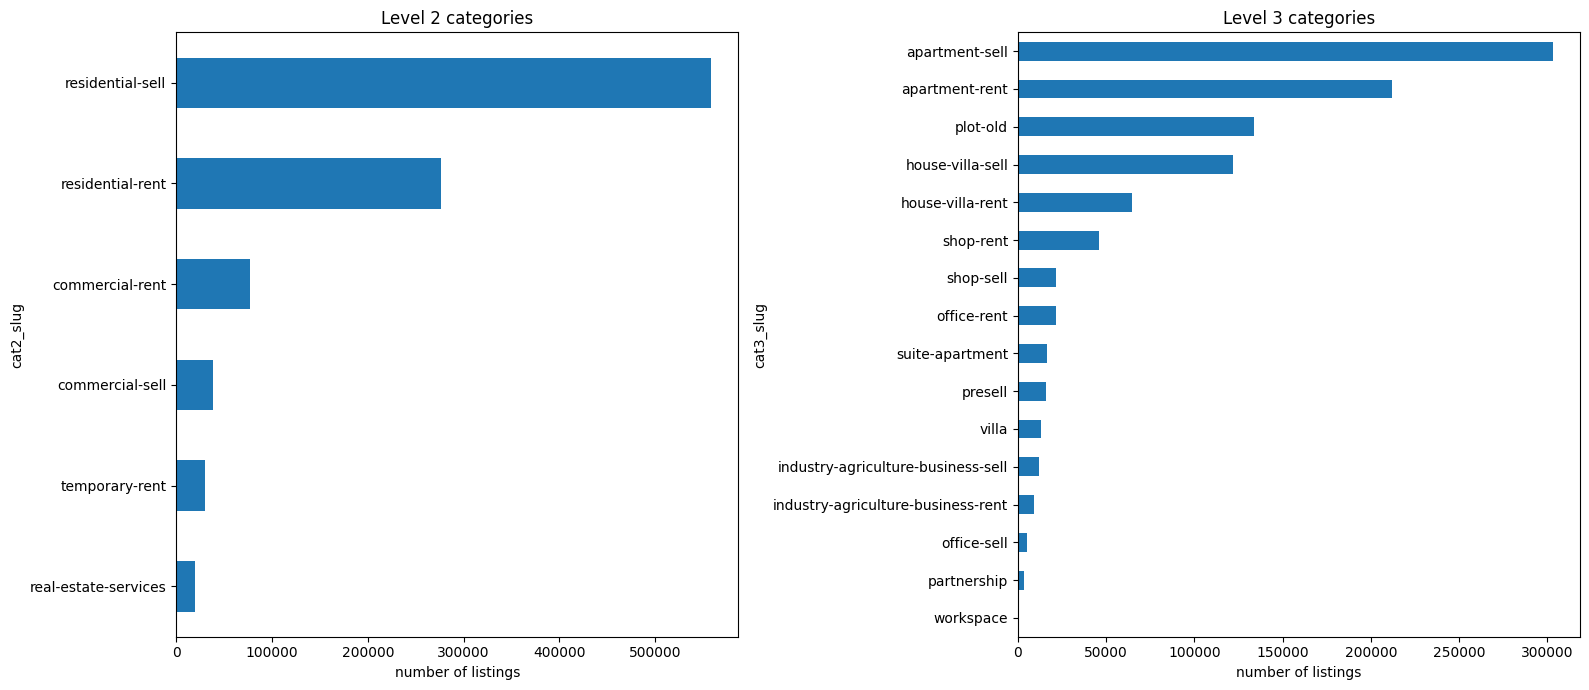

In [6]:
# category chart

fig, axes = plt.subplots(1,2,figsize=(16,7))
df_q1['cat2_slug'].value_counts()[::-1].plot(kind='barh',ax=axes[0])
axes[0].set_title('Level 2 categories')
axes[0].set_xlabel('number of listings')
df_q1['cat3_slug'].value_counts()[::-1].plot(kind='barh',ax=axes[1])
axes[1].set_title('Level 3 categories')
axes[1].set_xlabel('number of listings')
plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Residential ads are 83% of the data, so this dataset is essentially residential with a small commercial part</li>
<li>Sale ads are about twice the rentals</li>
<li>At level 3 a few large categories are followed by a long tail: apartment-sell alone is 30% while workspace is 0.05%</li>
<li>Horizontal bars, because the category names are long and overlap on a vertical chart</li>
</ul>
</font></div>

---
## ۲. سن بنا در آگهی‌های بازار

In [7]:
# the loaded frame is used directly from here on
data_frame = divar

**
First we need the construction_year column and city_slug to get the data and fill the Nan values grouped by the city_slug.**

In [8]:
# Get the needed columns
target_frame = data_frame[["construction_year"]]

# Changing the type pf the construction year from string to int.
persian_arabic_digits = "۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩"
english_digits = "01234567890123456789"
trans_table = str.maketrans(persian_arabic_digits, english_digits)

target_frame['construction_year'] = target_frame['construction_year'].str.translate(trans_table)

target_frame.head(10)

,construction_year
0,NaN
1,1384
2,1401
3,1400
4,1403
5,1389
6,1395
7,1393
8,1396
9,1387


In [9]:
# null counts for the columns this section relies on

target_frame.isna().sum()

construction_year    184172
dtype: int64

<Axes: title={'center': 'Distributions of the construction year'}, xlabel='Construction year', ylabel='Counts'>

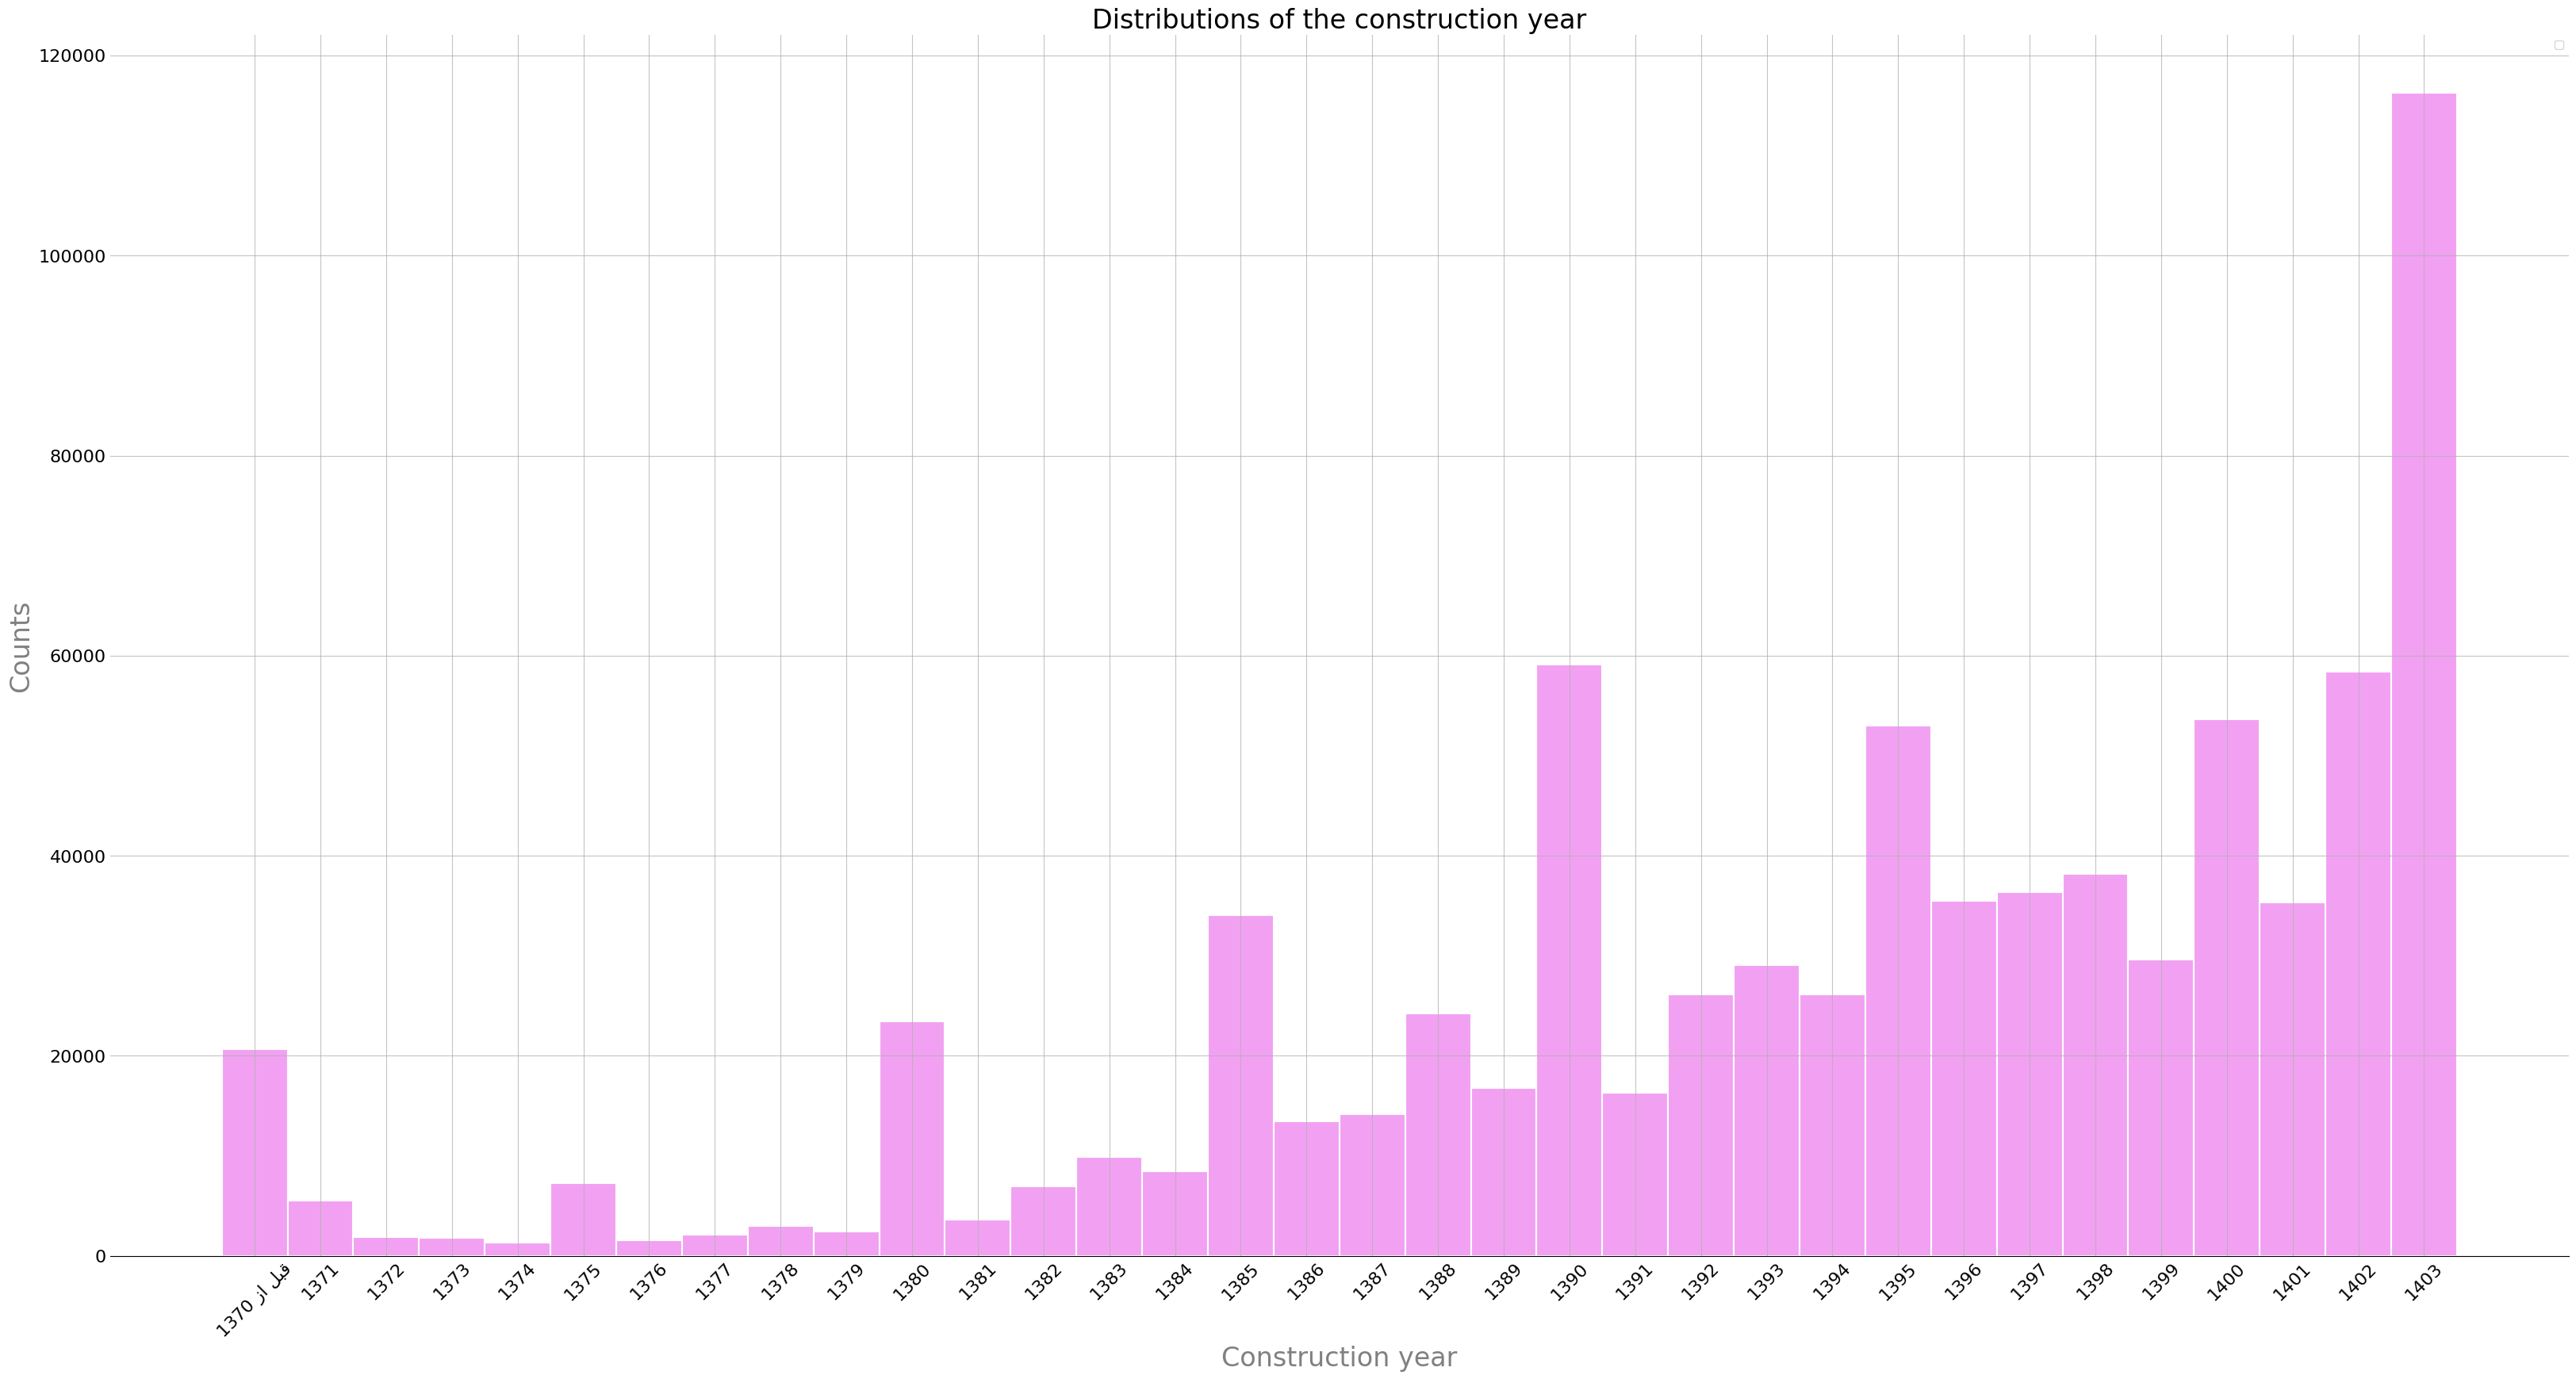

In [10]:
import arabic_reshaper
from bidi.algorithm import get_display

# we drop the Nan values.
target_frame = target_frame.dropna()
target_frame = target_frame.sort_values(by="construction_year")

# Sorting the years.
label_reshaped = get_display(arabic_reshaper.reshape("قبل از 1370"))
target_frame["construction_year"] = target_frame["construction_year"].replace(
    {"قبل از 1370": label_reshaped}
)

numeric_years = sorted(
    [
        int(y)
        for y in target_frame["construction_year"].unique()
        if str(y).isdigit()
    ]
)
numeric_years_str = [str(y) for y in numeric_years]

categories_order = [label_reshaped] + numeric_years_str

target_frame["construction_year"] = pd.Categorical(
    target_frame["construction_year"].astype(str),
    categories=categories_order,
    ordered=True,
)

target_frame = target_frame.sort_values(by="construction_year")

# Plotting the axes
figure, axis = plt.subplots(figsize=(40, 20))
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)
axis.set_title("Distributions of the construction year", fontsize=24)
axis.set_ylabel("Counts", fontsize=24, color="gray")
axis.set_xlabel("Construction year", fontsize=24, color="gray")
axis.tick_params(axis="y", length=0, labelsize=16)
axis.tick_params(axis="x", length=0, rotation=45, labelsize=16)
axis.grid(alpha=0.75)
axis.legend()


sns.histplot(target_frame["construction_year"],ax=axis,color="violet", edgecolor="white",linewidth=1.5)




<div dir="rtl">

- حدود ۱۸٪ آگهی‌ها سال ساخت ندارند و کنار گذاشته شدند.
- «قبل از ۱۳۷۰» یک دسته‌ی تجمیعی است؛ برای همین ستون اول بلندتر از سال‌های مجاور است و نباید آن را یک سال تنها خواند.
- بلندترین ستون **۱۴۰۳** است (حدود ۱۱۶ هزار آگهی): بخش بزرگی از عرضه نوساز یا پیش‌فروش است. احتمال هم دارد بعضی کاربران سال جاری را به‌جای سال واقعی انتخاب کرده باشند.
- سال‌های **رُند** (۱۳۸۰، ۱۳۸۵، ۱۳۹۰، ۱۳۹۵، ۱۴۰۰) جهش‌های واضحی دارند. این الگو (heaping) یعنی کاربرانی که سال دقیق را نمی‌دانند عدد گرد وارد می‌کنند؛ پس سال ساخت حدود دو سال عدم قطعیت دارد.
- هرچه به گذشته برویم تعداد آگهی‌ها کمتر می‌شود: ساختمان‌های قدیمی یا نوسازی شده‌اند یا کمتر آگهی می‌شوند.

</div>

---
## ۳. فصلی بودن عرضه: فروش و اجاره در ماه‌های سال

In [11]:
# split the listings into rental and sale ads by which price column is filled

labels = (data_frame["rent_value"]).isna()
rent_frame = data_frame[~labels]

labels = (data_frame["price_value"]).isna()
buy_frame = data_frame[~labels]

rent_frame

,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,rent_value,price_value,credit_value,land_size,building_size,...,has_warehouse,has_parking,construction_year,has_security_guard,has_barbecue,has_pool,has_jacuzzi,has_sauna,location_latitude,location_longitude
2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,26000000.0,NaN,7.500000e+08,NaN,132.0,...,True,True,۱۴۰۱,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459
3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,95000000.0,NaN,9.500000e+08,NaN,90.0,...,False,True,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,residential-rent,apartment-rent,ahvaz,mellirah,2024-09-01 00:00:00,6000000.0,NaN,2.500000e+08,NaN,100.0,...,True,True,۱۳۸۹,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,commercial-rent,office-rent,kermanshah,NaN,2024-11-01 00:00:00,16000000.0,NaN,1.500000e+08,NaN,80.0,...,False,False,۱۳۹۵,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,residential-rent,apartment-rent,tehran,gisha,2024-08-01 00:00:00,0.0,NaN,1.200000e+09,NaN,91.0,...,True,True,۱۳۸۵,NaN,NaN,NaN,NaN,NaN,35.733952,51.380608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999985,commercial-rent,shop-rent,parand-city,NaN,2024-07-01 00:00:00,100000.0,NaN,2.200000e+08,NaN,15.0,...,NaN,NaN,۱۳۹۸,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999987,residential-rent,apartment-rent,bonab,NaN,2024-10-01 00:00:00,3000000.0,NaN,3.000000e+07,NaN,85.0,...,False,False,۱۳۹۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN
999993,residential-rent,apartment-rent,mashhad,elahiyehblvd,2024-06-01 00:00:00,2000000.0,NaN,1.500000e+08,NaN,50.0,...,False,True,۱۳۸۶,NaN,NaN,NaN,NaN,NaN,36.374050,59.485794
999996,residential-rent,apartment-rent,tehran,darya,2024-07-01 00:00:00,45000000.0,NaN,1.000000e+09,NaN,110.0,...,True,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,35.770454,51.369099


In [12]:
from sklearn.preprocessing import FunctionTransformer

def trun_grogorian_solar_month(data_frame : pd.DataFrame):
  # Here we change the data type to the pd.DateTime.
  data_frame["created_at_month"] = pd.to_datetime(data_frame["created_at_month"])

  # Here we just take month and remove the created_at_month
  data_frame["month"] = data_frame["created_at_month"].dt.month

  # Here we turn the month of the Gregorian date into solar calender.
  map_gregorian_solar = {
      1 : "دی", 2 : "بهمن", 3 : "اسفند", 4 : "فروردین", 5 : "اردیبهشت", 6 : "خرداد",
      7 : "تیر", 8 : "مرداد", 9 : "شهریور", 10 : "مهر", 11 : "آبان", 12 : "آذر"
  }
  data_frame["month"] = data_frame["month"].map(map_gregorian_solar)
  data_frame = data_frame.drop(columns=["created_at_month"])

  return data_frame

# Enableing the function to be used in the PipeLine.
trun_grogorian_solar_month = FunctionTransformer(trun_grogorian_solar_month)
rent_frame = trun_grogorian_solar_month.transform(rent_frame)
buy_frame = trun_grogorian_solar_month.transform(buy_frame)

buy_frame.head(10)


,cat2_slug,cat3_slug,city_slug,neighborhood_slug,rent_value,price_value,credit_value,land_size,building_size,has_business_deed,...,has_parking,construction_year,has_security_guard,has_barbecue,has_pool,has_jacuzzi,has_sauna,location_latitude,location_longitude,month
1,residential-sell,apartment-sell,tehran,gholhak,NaN,8.500000e+09,NaN,NaN,60.0,NaN,...,True,۱۳۸۴,NaN,NaN,NaN,NaN,NaN,NaN,NaN,اردیبهشت
4,residential-sell,apartment-sell,mashhad,emamreza,NaN,5.750000e+09,NaN,NaN,115.0,NaN,...,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,NaN,NaN,اردیبهشت
7,residential-sell,apartment-sell,tehran,dardasht,NaN,8.700000e+09,NaN,NaN,100.0,NaN,...,True,۱۳۹۳,NaN,NaN,NaN,NaN,NaN,35.729832,51.505466,شهریور
8,residential-sell,apartment-sell,mahdasht-city,NaN,NaN,6.500000e+08,NaN,NaN,78.0,NaN,...,True,۱۳۹۶,NaN,NaN,NaN,NaN,NaN,35.712364,50.794781,خرداد
9,residential-sell,apartment-sell,mashhad,faramarzabbasi,NaN,3.000000e+09,NaN,NaN,80.0,NaN,...,True,۱۳۸۷,NaN,NaN,NaN,NaN,NaN,NaN,NaN,مهر
10,residential-sell,apartment-sell,pardis-city,NaN,NaN,2.600000e+09,NaN,NaN,87.0,NaN,...,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,35.778664,51.757549,آبان
12,residential-sell,apartment-sell,mashhad,farhang,NaN,1.299000e+10,NaN,NaN,169.0,NaN,...,True,۱۴۰۳,NaN,NaN,NaN,NaN,NaN,36.321831,59.524502,خرداد
13,commercial-sell,shop-sell,foolad-shahr,NaN,NaN,8.500000e+08,NaN,NaN,16.0,False,...,NaN,۱۴۰۰,NaN,NaN,NaN,NaN,NaN,32.467804,51.404095,تیر
14,residential-sell,plot-old,ahvaz,pardis-ahvaz,NaN,8.000000e+08,NaN,NaN,500.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.265947,48.568604,تیر
16,residential-sell,plot-old,tehran,shahrak-naft-district5,NaN,1.800000e+10,NaN,NaN,700.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.890186,51.280197,تیر


In [13]:
# monthly ad counts for each of the two markets

rent_frame = rent_frame.groupby("month").size().to_frame(name="count")
buy_frame = buy_frame.groupby("month").size().to_frame(name="count")

rent_frame

,count
month,
آبان,39541
آذر,36016
اردیبهشت,31150
اسفند,101
بهمن,73
تیر,51153
خرداد,46840
دی,318
شهریور,46979


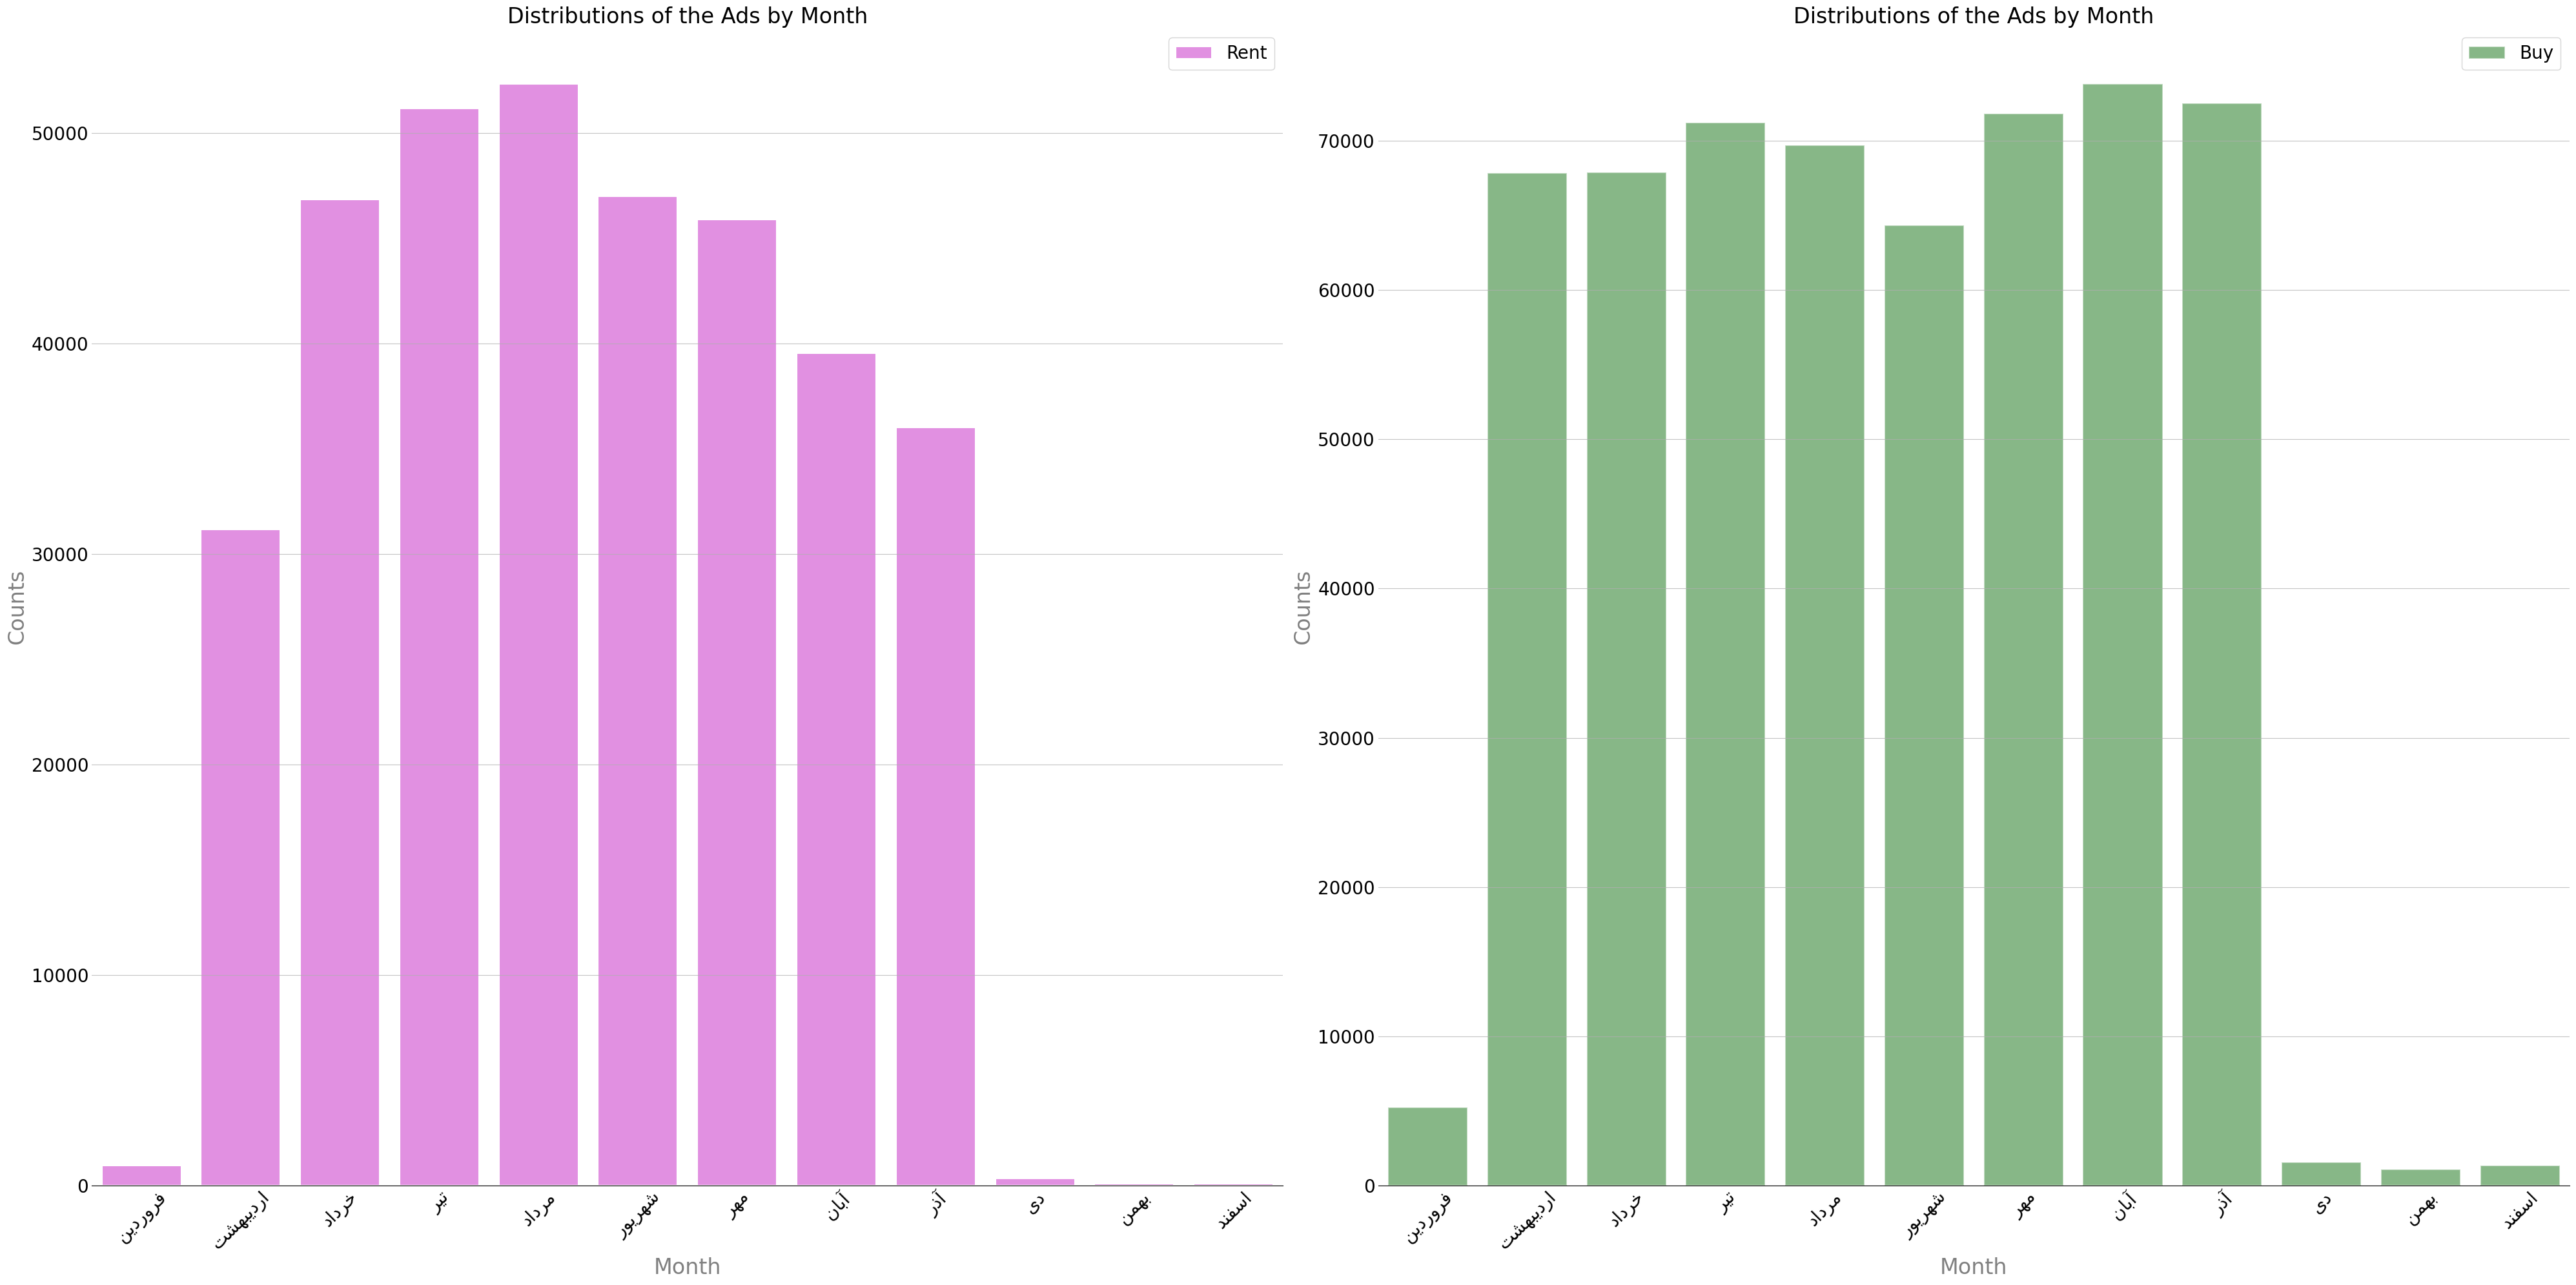

In [14]:
# start plotting.
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt
import seaborn as sns

def fix_fa(text: str) -> str:
    return get_display(arabic_reshaper.reshape(str(text)))


month_order = [
    "فروردین",
    "اردیبهشت",
    "خرداد",
    "تیر",
    "مرداد",
    "شهریور",
    "مهر",
    "آبان",
    "آذر",
    "دی",
    "بهمن",
    "اسفند",
]

rent_aligned = rent_frame.reindex(month_order, fill_value=0)
buy_aligned = buy_frame.reindex(month_order, fill_value=0)

x_labels = [fix_fa(m) for m in month_order]

figure, axis = plt.subplots(1, 2, figsize=(40, 20))

axis[0].spines["top"].set_visible(False)
axis[0].spines["right"].set_visible(False)
axis[0].spines["left"].set_visible(False)
axis[0].set_title("Distributions of the Ads by Month", fontsize=24)
axis[0].set_ylabel("Counts", fontsize=24, color="gray")
axis[0].set_xlabel("Month", fontsize=24, color="gray")
axis[0].tick_params(axis="y", length=0, labelsize=20)
axis[0].tick_params(axis="x", length=0, rotation=45, labelsize=20)
axis[0].grid(alpha=0.75)

sns.barplot(
    ax=axis[0],
    x=x_labels,
    y=rent_aligned["count"],
    color="violet",
    edgecolor="white",
    linewidth=1.5,
    alpha=1,
    label="Rent",
)

axis[0].legend(fontsize=20)

axis[1].spines["top"].set_visible(False)
axis[1].spines["right"].set_visible(False)
axis[1].spines["left"].set_visible(False)
axis[1].set_title("Distributions of the Ads by Month", fontsize=24)
axis[1].set_ylabel("Counts", fontsize=24, color="gray")
axis[1].set_xlabel("Month", fontsize=24, color="gray")
axis[1].tick_params(axis="y", length=0, labelsize=20)
axis[1].tick_params(axis="x", length=0, rotation=45, labelsize=20)
axis[1].grid(alpha=0.75)

sns.barplot(
    ax=axis[1],
    x=x_labels,
    y=buy_aligned["count"],
    color="green",
    edgecolor="white",
    linewidth=1.5,
    alpha=0.5,
    label="Buy",
)

axis[1].legend(fontsize=20)

plt.tight_layout()
plt.show()


<div dir="rtl">

- ماه‌ها با تاریخ روز اول ماه میلادی به ماه شمسی نگاشت شده‌اند (مثلاً ۱ می ≈ ۱۱ اردیبهشت).
- داده عملاً از اردیبهشت تا آذر را پوشش می‌دهد. دی تا فروردین فقط چند صد تا چند هزار آگهی دارند، پس افت این ماه‌ها مربوط به **پوشش داده** است، نه رفتار بازار.
- **اجاره** اوج فصلی واضحی دارد: از ۳۱ هزار آگهی در اردیبهشت به بیش از ۵۲ هزار در **تیر و مرداد** می‌رسد و تا آذر به ۳۶ هزار برمی‌گردد. این همان فصل جابه‌جایی تابستانی مستأجرهاست (تعطیلی مدارس و پایان قراردادها).
- **فروش** تقریباً یکنواخت است (۶۴ تا ۷۴ هزار آگهی در ماه)، با کمی افت در شهریور و بیشترین مقدار در **آبان** و آذر. یعنی عرضه‌ی اجاره فصلی است ولی عرضه‌ی فروش نه.

</div>

---
## ۴. توزیع قیمت فروش به تفکیک نوع ملک

In [15]:
# alias kept short for the price-cleaning steps below
df = divar

In [16]:
# how complete is price_value, and where are the gaps concentrated?
print("dtype           :", df["price_value"].dtype)
print("missing overall :", df["price_value"].isna().sum())
print("\nmissing price by category:")
print(df.groupby("cat3_slug")["price_value"].apply(lambda x: x.isna().sum()).sort_values(ascending=False).head(10))

dtype           : float64
missing overall : 431654

missing price by category:
cat3_slug
apartment-rent                        211876
house-villa-rent                       64676
shop-rent                              45970
plot-old                               23734
office-rent                            21412
suite-apartment                        16463
presell                                14577
villa                                  12898
industry-agriculture-business-rent      9150
partnership                             3616
Name: price_value, dtype: int64


In [17]:
# the twenty highest prices, to see whether the top of the range is real

df.nlargest(20, "price_value")[["cat3_slug", "price_value"]]

,cat3_slug,price_value
116854,apartment-sell,1.000000e+14
329748,plot-old,1.000000e+14
588194,house-villa-sell,1.000000e+14
740491,house-villa-sell,1.000000e+14
786984,house-villa-sell,1.000000e+14
927290,shop-sell,1.000000e+14
931774,plot-old,1.000000e+14
6406,apartment-sell,9.000000e+13
560251,apartment-sell,8.900000e+13
339009,apartment-sell,8.397000e+13


In [18]:
# prices at or above 1e13 toman: far beyond any real property

(df["price_value"] >= 1e13).sum()



np.int64(215)

In [19]:
# the same check one order of magnitude lower

(df["price_value"] >= 1e12).sum()

np.int64(615)

In [20]:
# zero prices are placeholders for "price on request", not free properties

(df["price_value"] == 0).sum()

np.int64(1902)

In [21]:
# which categories those zero prices come from

df[df["price_value"] == 0]["cat3_slug"].value_counts()

cat3_slug
house-villa-sell                      965
apartment-sell                        738
shop-sell                             114
industry-agriculture-business-sell     59
office-sell                            25
presell                                 1
Name: count, dtype: int64

In [22]:
# drop placeholder zeros and the typo-scale prices before plotting
df_price = df[
    (df["price_value"] > 0) &
    (df["price_value"] < 1e12)
]

len(df_price)

565829

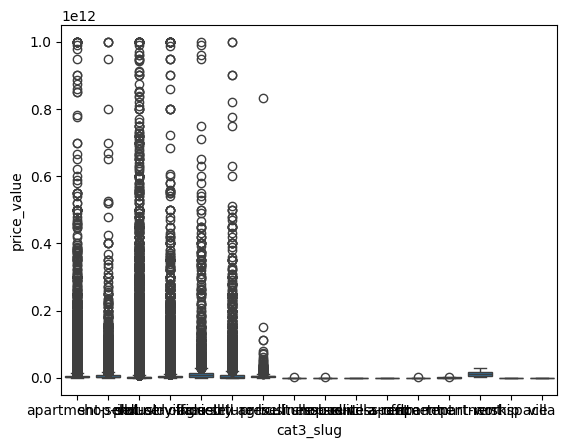

In [23]:
# price spread per category on the cleaned frame

sns.boxplot(data=df_price, x="cat3_slug", y="price_value")
plt.show()

<div dir="rtl">

نمودار بالا روی مقیاس خطی خوانا نیست، چون چند آگهی با قیمت‌هایی مثل ۱۰<sup>۱۴</sup> تومان (اشتباه تایپی) محور را کش می‌دهند.
در نسخه‌ی زیر فقط دسته‌های فروش آمده‌اند، قیمت صفر («توافقی») حذف شده، محور لگاریتمی است و دسته‌ها به ترتیب میانه مرتب شده‌اند.

</div>

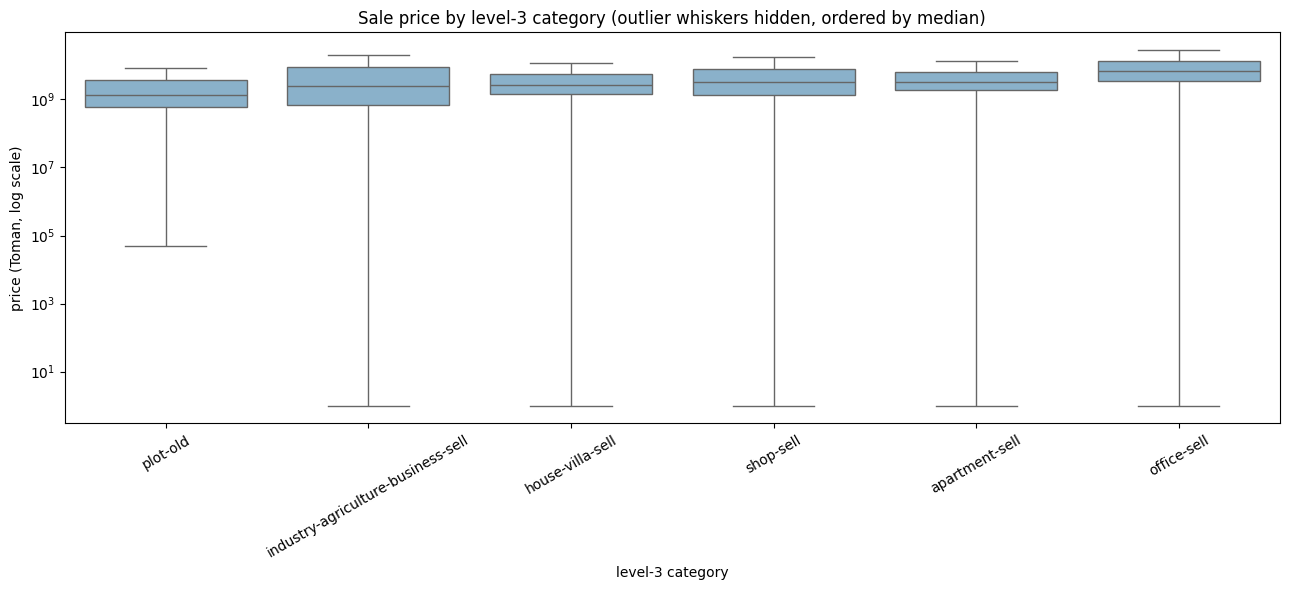

cat3_slug
plot-old                              1.35
industry-agriculture-business-sell    2.50
house-villa-sell                      2.70
shop-sell                             3.20
apartment-sell                        3.30
office-sell                           6.80
Name: median (billion Toman), dtype: float64


In [24]:
# sale prices per category, ordered by median, on a log axis

sell = divar.loc[divar["cat2_slug"].str.endswith("-sell") & (divar["price_value"] > 0), ["cat3_slug", "price_value"]]
order = sell.groupby("cat3_slug")["price_value"].median().sort_values().index

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=sell, x="cat3_slug", y="price_value", order=order, showfliers=False, color="#7fb3d5", ax=ax)
ax.set_yscale("log")
ax.set_xlabel("level-3 category")
ax.set_ylabel("price (Toman, log scale)")
ax.set_title("Sale price by level-3 category (outlier whiskers hidden, ordered by median)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print((sell.groupby("cat3_slug")["price_value"].median() / 1e9).round(2).sort_values().rename("median (billion Toman)"))

<div dir="rtl">

- ارزان‌ترین دسته‌ها از نظر میانه **زمین/کلنگی** و آپارتمان‌اند و گران‌ترین‌ها دسته‌های تجاری و صنعتی.
- پراکندگی درون هر دسته چند مرتبه‌ی بزرگی است؛ برای همین در همه‌ی تحلیل‌های بعدی قیمت را روی مقیاس لگاریتمی پاک‌سازی و مقایسه کرده‌ایم.

</div>

---
## ۵. تراکم جغرافیایی عرضه

In [25]:
#q5
df["location_latitude"].dtype

df["location_longitude"].dtype

df["location_latitude"].isnull().sum()

print(df["location_latitude"].count())

655608


In [26]:
# coordinates only, dropping the third of listings that have none

geo_df = df[["location_latitude", "location_longitude"]]
geo_df = geo_df.dropna()
geo_df.describe()

,location_latitude,location_longitude
count,655608.000000,655608.000000
mean,34.982108,51.629743
std,2.379169,3.160920
min,23.626478,40.162369
25%,34.553551,50.677175
50%,35.723312,51.345791
75%,36.307013,51.805291
max,40.358055,74.511620


In [27]:
# centre the map on the middle of the listings rather than a hardcoded point
center_lat = geo_df["location_latitude"].mean()
center_lon = geo_df["location_longitude"].mean()

print(f"map centre: {center_lat:.4f}, {center_lon:.4f}")

map centre: 34.9821, 51.6297


In [28]:
# base map, centred on the coordinates computed above
m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6
)

m

In [29]:
# folium expects a plain array of lat/lon pairs

hitmap=geo_df.to_numpy()

In [30]:
# overlay the density layer on the base map

HeatMap(hitmap).add_to(m)


In [31]:
out = MAPS_DIR / "q5_heatmap.html"
m.save(str(out))

# the map embeds ~650k points, so it is written to disk and opened from there
# rather than rendered inline, which would make this notebook too large to view
print(f"saved {out}  ({out.stat().st_size / 1e6:.0f} MB)")


saved ..\outputs\maps\q5_heatmap.html  (26 MB)


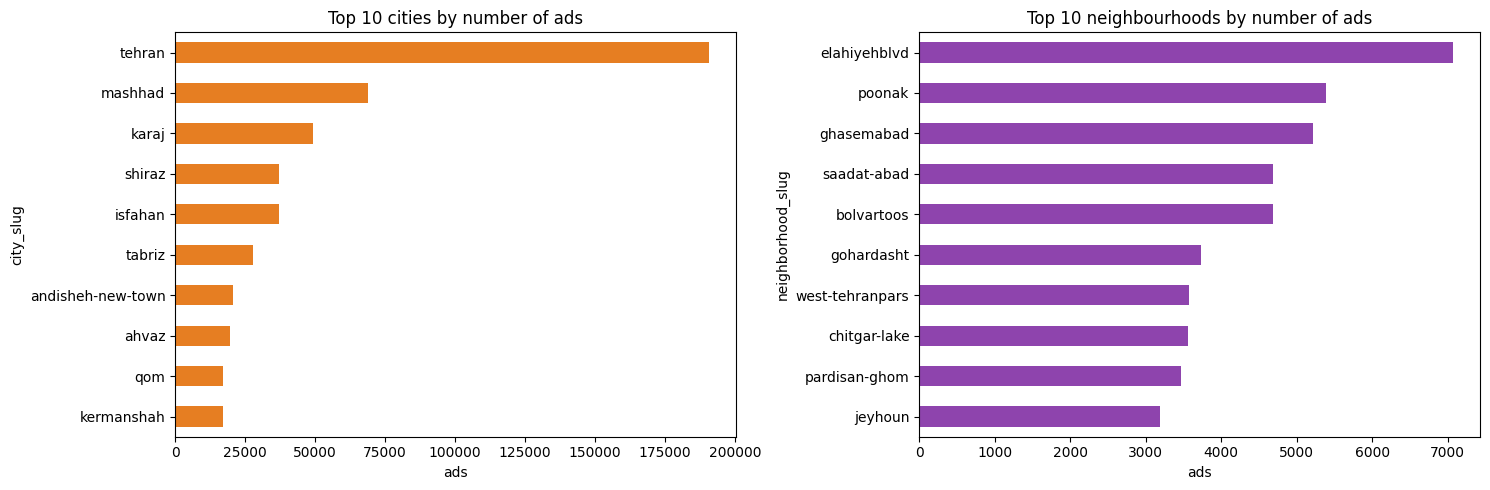

In [32]:
# where the listings come from: the busiest cities and neighbourhoods

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
divar["city_slug"].value_counts().head(10)[::-1].plot(kind="barh", ax=axes[0], color="#e67e22")
axes[0].set_title("Top 10 cities by number of ads")
divar["neighborhood_slug"].value_counts().head(10)[::-1].plot(kind="barh", ax=axes[1], color="#8e44ad")
axes[1].set_title("Top 10 neighbourhoods by number of ads")
for ax in axes:
    ax.set_xlabel("ads")
plt.tight_layout()
plt.show()

بررسی نقشه‌ی Heatmap نشان می‌دهد که آگهی‌ها در سراسر کشور به‌صورت یکنواخت توزیع نشده‌اند و تمرکز قابل‌توجهی در برخی مناطق شهری مشاهده می‌شود. بیشترین تراکم فضایی آگهی‌ها در محدوده‌ی تهران و نواحی پیرامون آن دیده می‌شود و پس از آن، شهرهایی مانند مشهد، کرج، شیراز و اصفهان نیز دارای تجمع قابل‌توجهی از آگهی‌ها هستند. این الگو نشان می‌دهد که بخش عمده‌ای از فعالیت موجود در داده‌ها در مراکز جمعیتی و شهری بزرگ متمرکز است.
این برداشت با شمارش آگهی‌ها بر اساس شهر نیز همخوانی دارد. در میان شهرها، تهران با ۱۹۰٬۹۰۴ آگهی بیشترین تعداد آگهی را دارد و پس از آن مشهد با ۶۹٬۰۳۲ آگهی و کرج با ۴۹٬۳۶۷ آگهی قرار دارند. بنابراین، تراکم بالاتر نواحی شهری بزرگ در نقشه با تعداد بیشتر آگهی‌های ثبت‌شده در این شهرها نیز سازگار است.
در سطح منطقه‌ای، بررسی ستون neighborhood_slug نشان داد که منطقه‌ی elahiyehblvd در شهر مشهد با ۷٬۰۷۶ آگهی بیشترین تعداد آگهی را در میان مناطق ثبت‌شده دارد. در نتیجه، Heatmap علاوه بر نشان دادن تمرکز کلی آگهی‌ها در مراکز شهری، وجود نقاطی با تمرکز بالاتر در داخل شهرها را نیز نشان می‌دهد.

---
## ۶. روند اجاره در تقویم شمسی

<div dir="rtl">

نسخه‌ی اول این سؤال میانگین خام `rent_value` را می‌گرفت. این ستون مقدارهایی تا ۱۰<sup>۱۵</sup> تومان دارد و
چند آگهی اشتباه میانگین را می‌سازند، پس ترند به‌دست‌آمده معنایی نداشت. در این نسخه:

1. فقط **اجاره‌ی مسکونی** با اجاره‌ی مثبت آمده (اجاره‌ی صفر یعنی «رهن کامل»).
2. مقادیر پرت با IQR روی لگاریتم حذف شده‌اند.
3. ماه‌ها به‌صورت زمانی پشت سر هم (و نه فقط اسم ماه) با برچسب شمسی رسم شده‌اند و میانگین و میانه کنار هم آمده‌اند.
4. چون اجاره و رهن با هم معامله می‌شوند، **اجاره‌ی معادل** هم رسم شده است: طبق تعریف صورت پروژه، هر یک میلیون تومان رهن معادل ۳۰ هزار تومان اجاره‌ی ماهانه است.

</div>

In [33]:
# rent and deposit are traded against each other, so convert to one equivalent rent

rent = divar.loc[divar["cat2_slug"].eq("residential-rent"), ["created_at_month", "rent_value", "credit_value"]].copy()
rent["month"] = pd.to_datetime(rent["created_at_month"])
rent["equivalent_rent"] = rent["rent_value"].fillna(0) + 0.03 * rent["credit_value"].fillna(0)

monthly_rent = rent[(rent["rent_value"] > 0) & log_iqr_mask(rent["rent_value"])]
equivalent = rent[log_iqr_mask(rent["equivalent_rent"])]


def monthly_trend(frame, column):
    trend = frame.groupby("month")[column].agg(["size", "mean", "median"])
    jalali = [to_jalali(m) for m in trend.index]
    trend["label"] = [f"{JALALI_MONTHS[j.month - 1]} {j.year}" for j in jalali]
    return trend


rent_trend = monthly_trend(monthly_rent, "rent_value")
equivalent_trend = monthly_trend(equivalent, "equivalent_rent").reindex(rent_trend.index)
print(rent_trend.assign(mean=lambda t: (t["mean"] / 1e6).round(2), median=lambda t: (t["median"] / 1e6).round(2)))

             size   mean  median          label
month                                          
2022-06-01      1  75.00    75.0     خرداد 1401
2022-07-01      1  45.00    45.0       تیر 1401
2022-08-01      1  70.00    70.0     مرداد 1401
2023-08-01      1  65.00    65.0     مرداد 1402
2023-09-01      1  30.00    30.0    شهریور 1402
2023-11-01      3  23.47     6.6      آبان 1402
2023-12-01      3  52.67    30.0       آذر 1402
2024-01-01      9  38.61    30.0        دی 1402
2024-02-01     16  27.47    16.5      بهمن 1402
2024-03-01     25  21.72    15.0     اسفند 1402
2024-04-01    347  19.96    10.0   فروردین 1403
2024-05-01  15051  12.88     7.0  اردیبهشت 1403
2024-06-01  25830  10.77     6.0     خرداد 1403
2024-07-01  29049  10.85     6.0       تیر 1403
2024-08-01  29954  11.04     6.0     مرداد 1403
2024-09-01  27029  11.24     6.0    شهریور 1403
2024-10-01  24762  12.19     7.0       مهر 1403
2024-11-01  20510  12.35     7.0      آبان 1403
2024-12-01  18009  12.79     7.0       آ

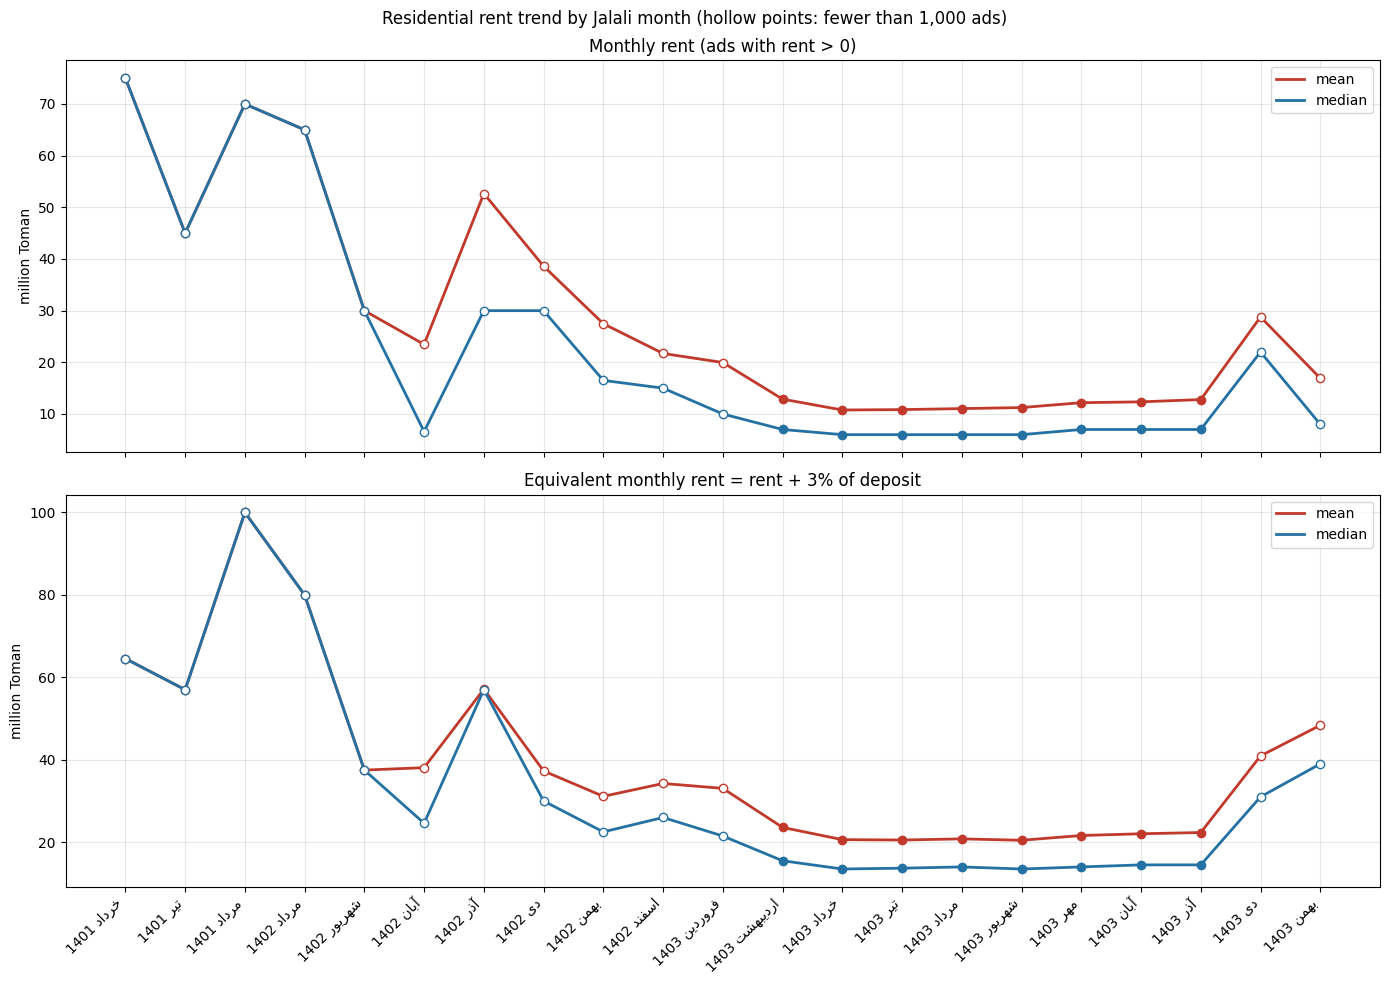

In [34]:
# monthly trend, drawing thin months hollow so they are not read as signal

MIN_ADS = 1000  # months with fewer ads are drawn hollow: too few ads for a stable average

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
for ax, trend, title in [
    (axes[0], rent_trend, "Monthly rent (ads with rent > 0)"),
    (axes[1], equivalent_trend, "Equivalent monthly rent = rent + 3% of deposit"),
]:
    x = np.arange(len(trend))
    enough = trend["size"] >= MIN_ADS
    for column, colour in [("mean", "#c0392b"), ("median", "#2471a3")]:
        values = trend[column] / 1e6
        ax.plot(x, values, color=colour, linewidth=2, label=column)
        ax.scatter(x[enough], values[enough], color=colour, zorder=3)
        ax.scatter(x[~enough], values[~enough], facecolors="white", edgecolors=colour, zorder=3)
    ax.set_title(title)
    ax.set_ylabel("million Toman")
    ax.grid(alpha=0.3)
    ax.legend()
axes[1].set_xticks(np.arange(len(rent_trend)))
axes[1].set_xticklabels([fix_fa(label) for label in rent_trend["label"]], rotation=45, ha="right")
plt.suptitle("Residential rent trend by Jalali month (hollow points: fewer than 1,000 ads)")
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر (بعد از اجرا با اعداد نهایی چک شود):**
- میانه همیشه پایین‌تر از میانگین است؛ توزیع اجاره به‌شدت راست‌چوله است و چند واحد لوکس میانگین را بالا می‌کشند. برای «اجاره‌ی معمول» میانه معیار بهتری است.
- ماه‌هایی که با دایره‌ی توخالی مشخص شده‌اند نمونه‌ی کمی دارند و نباید روی آن‌ها نتیجه‌گیری کرد.
- روند ماه‌های پرنمونه (اردیبهشت تا آذر ۱۴۰۳) نشان می‌دهد اجاره در طول سال بالا می‌رود؛ بخشی از این رشد تورم است و بخشی فصل جابه‌جایی تابستان.

</div>

---
## ۷. قیمت اسمی در برابر قیمت حقیقی (۱۴۰۰ تا ۱۴۰۳)

<div dir="rtl">

**روش محاسبه‌ی قیمت حقیقی**

- قیمت حقیقی = قیمت اسمی × CPI<sub>سال پایه</sub> / CPI<sub>سال آگهی</sub>، با **۱۴۰۰ به‌عنوان سال پایه**.
- شاخص CPI (شاخص قیمت مصرف‌کننده) از گزارش‌های سالانه‌ی مرکز آمار ایران گرفته شده است.
- برای اینکه ترکیب ملک‌ها (زمین، ویلا، آپارتمان) نتیجه را عوض نکند، مقایسه‌ی اصلی روی **فروش آپارتمان** انجام شده و کل فروش مسکونی هم برای مقایسه آمده است.
- داده آگهی‌ای از سال ۱۴۰۰ ندارد (قدیمی‌ترین ماه، خرداد ۱۴۰۱ است)؛ ۱۴۰۰ فقط نقش سال پایه را دارد.

</div>

In [35]:
# deflate nominal prices by CPI to get real prices in 1400 money

CPI = {1400: 719, 1401: 1031, 1402: 1480, 1403: 2140}
BASE_YEAR = 1400

sale = divar.loc[divar["cat2_slug"].eq("residential-sell") & (divar["price_value"] > 0),
                 ["cat3_slug", "price_value", "created_at_month"]].copy()
sale = sale[log_iqr_mask(sale["price_value"])]
sale["year"] = pd.to_datetime(sale["created_at_month"]).map(lambda d: to_jalali(d).year)


def yearly_prices(frame):
    yearly = frame.groupby("year")["price_value"].agg(n="size", nominal_mean="mean", nominal_median="median")
    yearly = yearly[yearly.index.isin(CPI)]
    factor = CPI[BASE_YEAR] / yearly.index.map(CPI).to_numpy()
    yearly["real_mean"] = yearly["nominal_mean"] * factor
    yearly["real_median"] = yearly["nominal_median"] * factor
    return yearly


apartments = yearly_prices(sale[sale["cat3_slug"].eq("apartment-sell")])
residential = yearly_prices(sale)

print("apartment-sell (billion Toman, real values in 1400 prices)")
print(apartments.assign(**{c: apartments[c] / 1e9 for c in apartments.columns if c != "n"}).round(2))
print()
print("all residential-sell")
print(residential.assign(**{c: residential[c] / 1e9 for c in residential.columns if c != "n"}).round(2))

apartment-sell (billion Toman, real values in 1400 prices)
           n  nominal_mean  nominal_median  real_mean  real_median
year                                                              
1401       8          3.78            2.54       2.64         1.77
1402    1255          6.13            3.63       2.98         1.76
1403  290872          5.38            3.35       1.81         1.13

all residential-sell
           n  nominal_mean  nominal_median  real_mean  real_median
year                                                              
1400       3          1.07            1.20       1.07         1.20
1401      40          3.52            2.00       2.45         1.39
1402    3789          4.87            2.65       2.36         1.29
1403  501417          4.91            2.90       1.65         0.97


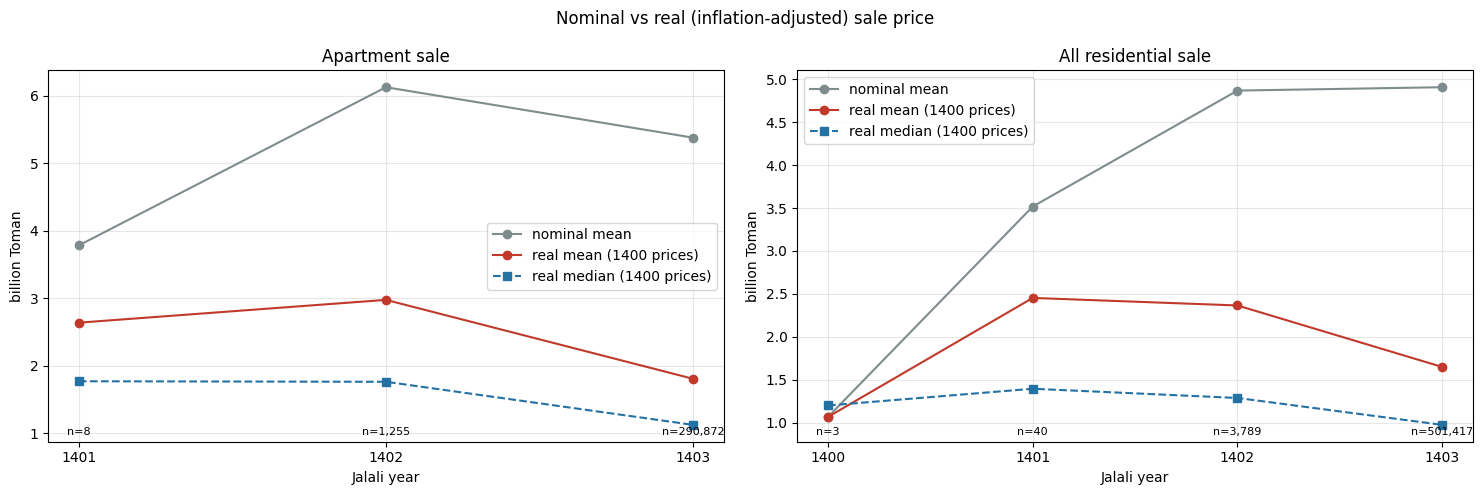

In [36]:
# nominal against real, for apartments and for all residential sales

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=False)
for ax, yearly, title in [(axes[0], apartments, "Apartment sale"), (axes[1], residential, "All residential sale")]:
    years = yearly.index.astype(str)
    ax.plot(years, yearly["nominal_mean"] / 1e9, marker="o", color="#7f8c8d", label="nominal mean")
    ax.plot(years, yearly["real_mean"] / 1e9, marker="o", color="#c0392b", label=f"real mean ({BASE_YEAR} prices)")
    ax.plot(years, yearly["real_median"] / 1e9, marker="s", linestyle="--", color="#2471a3", label=f"real median ({BASE_YEAR} prices)")
    for year, n in zip(years, yearly["n"]):
        ax.annotate(f"n={n:,}", (year, 0), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8,
                    xycoords=("data", "axes fraction"))
    ax.set_title(title)
    ax.set_xlabel("Jalali year")
    ax.set_ylabel("billion Toman")
    ax.grid(alpha=0.3)
    ax.legend()
plt.suptitle("Nominal vs real (inflation-adjusted) sale price")
plt.tight_layout()
plt.show()

<div dir="rtl">

**تفسیر (بعد از اجرا با اعداد نهایی چک شود):**
- قیمت اسمی هر سال بالاتر از سال قبل است، ولی تورم سالانه‌ی ۴۰ تا ۴۵ درصدی بخش بزرگی از این رشد را توضیح می‌دهد.
- منحنی قیمت حقیقی نشان می‌دهد ارزش واقعی ملک تقریباً ثابت مانده یا رشد بسیار کمتری از قیمت اسمی داشته است.
- تعداد آگهی‌های ۱۴۰۱ کم است (چند ماه آخر داده)، پس نقطه‌ی آن سال عدم قطعیت بیشتری دارد.

</div>

---
## ۸. هم‌بستگی ویژگی‌های ملک با قیمت

In [37]:
# sample rows

df_cheak = pd.read_csv('../data/Divar.csv',nrows=1000)

In [38]:
# column types

df_cheak.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 61 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  1000 non-null   int64  
 1   cat2_slug                   1000 non-null   str    
 2   cat3_slug                   1000 non-null   str    
 3   city_slug                   1000 non-null   str    
 4   neighborhood_slug           438 non-null    str    
 5   created_at_month            1000 non-null   str    
 6   user_type                   288 non-null    str    
 7   description                 1000 non-null   str    
 8   title                       1000 non-null   str    
 9   rent_mode                   330 non-null    str    
 10  rent_value                  328 non-null    float64
 11  rent_to_single              0 non-null      float64
 12  rent_type                   101 non-null    str    
 13  price_mode                  599 non-null    s

In [39]:
# first rows

df_cheak.head()

,Unnamed: 0,cat2_slug,cat3_slug,city_slug,neighborhood_slug,created_at_month,user_type,description,title,rent_mode,...,property_type,regular_person_capacity,extra_person_capacity,cost_per_extra_person,rent_price_on_regular_days,rent_price_on_special_days,rent_price_at_weekends,location_latitude,location_longitude,location_radius
0,0,temporary-rent,villa,karaj,mehrshahr,2024-08-01 00:00:00,مشاور املاک,۵۰۰متر\n۲۰۰متر بنا دوبلکس\n۳خواب\nاستخر آبگرم ...,باغ ویلا اجاره روزانه استخر داخل لشکرآباد سهیلیه,NaN,...,NaN,4.0,6.0,350000.0,1500000.0,3.500000e+09,3500000.0,35.811684,50.936600,500.0
1,1,residential-sell,apartment-sell,tehran,gholhak,2024-05-01 00:00:00,مشاور املاک,دسترسی عالی به مترو و شریعتی \nمشاعات تمیز \nب...,۶۰ متر قلهک فول امکانات,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,500.0
2,2,residential-rent,apartment-rent,tehran,tohid,2024-10-01 00:00:00,NaN,تخلیه پایان ماه,آپارتمان ۳ خوابه ۱۳۲ متر,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.703865,51.373459,NaN
3,3,commercial-rent,office-rent,tehran,elahiyeh,2024-06-01 00:00:00,NaN,فرشته تاپ لوکیشن\n۹۰ متر موقعیت اداری\nیک اتاق...,فرشته ۹۰ متر دفتر کار مدرن موقعیت اداری,مقطوع,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,residential-sell,apartment-sell,mashhad,emamreza,2024-05-01 00:00:00,مشاور املاک,هلدینگ ساختمانی اکبری\n\nهمراه شما هستیم برای ...,۱۱۵ متری/شمالی رو به آفتاب/اکبری,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [40]:
# load Q8 columns

q8_columns = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude','city_slug','cat3_slug']
df = pd.read_csv('../data/Divar.csv',usecols=q8_columns)
df.shape

(1000000, 9)

In [41]:
# null check

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 9 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   cat3_slug                999999 non-null  str    
 1   city_slug                999998 non-null  str    
 2   price_value              568346 non-null  float64
 3   land_size                186396 non-null  float64
 4   building_size            980394 non-null  float64
 5   rooms_count              845899 non-null  str    
 6   regular_person_capacity  29870 non-null   float64
 7   location_latitude        655608 non-null  float64
 8   location_longitude       655608 non-null  float64
dtypes: float64(6), str(3)
memory usage: 68.7 MB


In [42]:
# impossible values

df.describe().T

,count,mean,std,min,25%,50%,75%,max
price_value,568346.0,1.736537e+10,5.878739e+11,0.000000,1.400000e+09,2.840000e+09,5.900000e+09,1.000000e+14
land_size,186396.0,4.165480e+03,1.218927e+05,1.000000,1.100000e+02,1.950000e+02,2.800000e+02,1.000000e+07
building_size,980394.0,4.440648e+03,1.367118e+05,1.000000,7.500000e+01,1.030000e+02,1.650000e+02,1.000000e+07
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655608.0,3.498211e+01,2.379169e+00,23.626478,3.455355e+01,3.572331e+01,3.630701e+01,4.035806e+01
location_longitude,655608.0,5.162974e+01,3.160920e+00,40.162369,5.067717e+01,5.134579e+01,5.180529e+01,7.451162e+01


In [43]:
# rooms values

df['rooms_count'].value_counts(dropna=False)

rooms_count
دو              404050
یک              192083
NaN             154101
سه              138633
بدون اتاق        75898
چهار             21371
پنج یا بیشتر     13864
Name: count, dtype: int64

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Dropped zero prices, they are negotiable-price ads and not real prices</li>
<li>Log first, then IQR, because price and size are heavily skewed and a plain IQR would treat genuinely expensive properties as outliers</li>
<li>This removed about 5.8% of prices, 9.4% of building sizes and 3.8% of land sizes, which is normal for user-written ads</li>
<li>rooms_count was text and was mapped to 0-5, and 47 rows with coordinates outside Iran were dropped</li>
</ul>
</font></div>

In [44]:
# cleaning

df_q8 = df.copy()

print(df_q8['price_value'].quantile([0.99,0.999,0.9999]))
print(df_q8['price_value'].sort_values(ascending=False).head(20))

print(df_q8['land_size'].quantile([0.99,0.999,0.9999]))
print(df_q8['land_size'].sort_values(ascending=False).head(20))

print(df_q8['building_size'].quantile([0.99,0.999,0.9999]))
print(df_q8['building_size'].sort_values(ascending=False).head(20))

q8_mapping = {'بدون اتاق':0,'یک':1,'دو':2,'سه':3,'چهار':4,'پنج یا بیشتر':5}

df_q8['rooms_count'] = df_q8['rooms_count'].map(q8_mapping)

df_q8.loc[df_q8['price_value'] <= 0,'price_value'] = np.nan
df_q8.loc[df_q8['land_size'] <= 0,'land_size'] = np.nan
df_q8.loc[df_q8['building_size'] <= 0,'building_size'] = np.nan

def clean_outliers_log(data, column):
    logs = np.log(data[column])
    q1, q3 = logs.quantile(0.25), logs.quantile(0.75)
    iqr = q3 - q1
    data.loc[~logs.between(q1 - 1.5 * iqr, q3 + 1.5 * iqr),column] = np.nan
    return data


columns_cheak_outlier = ['land_size','price_value','building_size']
for column in columns_cheak_outlier:
    print('before:',df_q8[column].isna().sum())
    df_q8 = clean_outliers_log(df_q8, column)
    print('after:',df_q8[column].isna().sum())

df_q8.loc[~((df_q8['location_latitude'].between(25,40)) & (df_q8['location_longitude'].between(44,63.5))), ['location_latitude','location_longitude']] = np.nan
print(df_q8.isna().sum())

df_q8.describe().T

0.9900    8.500000e+10
0.9990    1.111111e+12
0.9999    1.970000e+13
Name: price_value, dtype: float64
329748    1.000000e+14
116854    1.000000e+14
588194    1.000000e+14
786984    1.000000e+14
931774    1.000000e+14
927290    1.000000e+14
740491    1.000000e+14
6406      9.000000e+13
560251    8.900000e+13
339009    8.397000e+13
306779    8.000086e+13
178219    7.000000e+13
388408    6.400000e+13
9201      6.300000e+13
703415    6.160000e+13
51259     6.000000e+13
209643    5.150000e+13
328774    5.000000e+13
564384    5.000000e+13
60067     5.000000e+13
Name: price_value, dtype: float64
0.9900    4.320650e+03
0.9990    1.100000e+06
0.9999    8.180250e+06
Name: land_size, dtype: float64
176035    10000000.0
145526    10000000.0
535334    10000000.0
534250    10000000.0
229017    10000000.0
905101    10000000.0
901197    10000000.0
336726    10000000.0
171954    10000000.0
173270    10000000.0
481516    10000000.0
449438    10000000.0
734403    10000000.0
236786     9250000.0
331890  

before: 813604
after: 820616
before: 433556
after: 464436
before: 19606
after: 112173


cat3_slug                       1
city_slug                       2
price_value                464436
land_size                  820616
building_size              112173
rooms_count                154101
regular_person_capacity    970130
location_latitude          344439
location_longitude         344439
dtype: int64


,count,mean,std,min,25%,50%,75%,max
price_value,535564.0,5.088866e+09,6.479189e+09,1.640000e+08,1.500000e+09,2.950000e+09,5.810000e+09,5.100000e+10
land_size,179384.0,2.292650e+02,1.848719e+02,2.800000e+01,1.100000e+02,1.850000e+02,2.600000e+02,1.137000e+03
building_size,887827.0,1.274276e+02,8.525152e+01,2.300000e+01,7.500000e+01,1.000000e+02,1.500000e+02,5.380000e+02
rooms_count,845899.0,1.857061e+00,9.889369e-01,0.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
regular_person_capacity,29870.0,6.557650e+00,7.698655e+00,1.000000e+00,3.000000e+00,4.000000e+00,7.000000e+00,5.000000e+01
location_latitude,655561.0,3.498264e+01,2.377957e+00,2.501717e+01,3.455394e+01,3.572332e+01,3.630702e+01,3.980854e+01
location_longitude,655561.0,5.162953e+01,3.160282e+00,4.400128e+01,5.067718e+01,5.134577e+01,5.180507e+01,6.284333e+01


In [45]:
# pairwise counts

q8_cols = ['price_value','land_size','building_size','regular_person_capacity','rooms_count','location_latitude','location_longitude']
pair_counts = pd.DataFrame(index=q8_cols,columns=q8_cols)

for a in q8_cols:
    for b in q8_cols:
        both = (df_q8[a].notna()) & (df_q8[b].notna())
        pair_counts.loc[a, b] = both.sum()

pair_counts

,price_value,land_size,building_size,regular_person_capacity,rooms_count,location_latitude,location_longitude
price_value,535564,108086,493000,0,432391,352058,352058
land_size,108086,179384,173862,0,179384,109401,109401
building_size,493000,173862,887827,23025,790574,585931,585931
regular_person_capacity,0,0,23025,29870,29870,19448,19448
rooms_count,432391,179384,790574,29870,845899,559277,559277
location_latitude,352058,109401,585931,19448,559277,655561,655561
location_longitude,352058,109401,585931,19448,559277,655561,655561


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>This table shows how many rows sit behind each cell of the matrix</li>
<li>Price and capacity share zero rows</li>
<li>Capacity is only filled for villas and daily suites while price belongs to sale ads, so that cell of the matrix stays empty</li>
</ul>
</font></div>

                         price_value  land_size  building_size  \
price_value                 1.000000   0.225383       0.218375   
land_size                   0.225383   1.000000       0.331325   
building_size               0.218375   0.331325       1.000000   
regular_person_capacity          NaN        NaN       0.223118   
rooms_count                 0.349004   0.203978       0.560222   
location_latitude           0.024414   0.058515      -0.061798   
location_longitude         -0.002199   0.033481       0.025758   

                         regular_person_capacity  rooms_count  \
price_value                                  NaN     0.349004   
land_size                                    NaN     0.203978   
building_size                           0.223118     0.560222   
regular_person_capacity                 1.000000     0.344266   
rooms_count                             0.344266     1.000000   
location_latitude                      -0.046471    -0.021110   
location_longitu

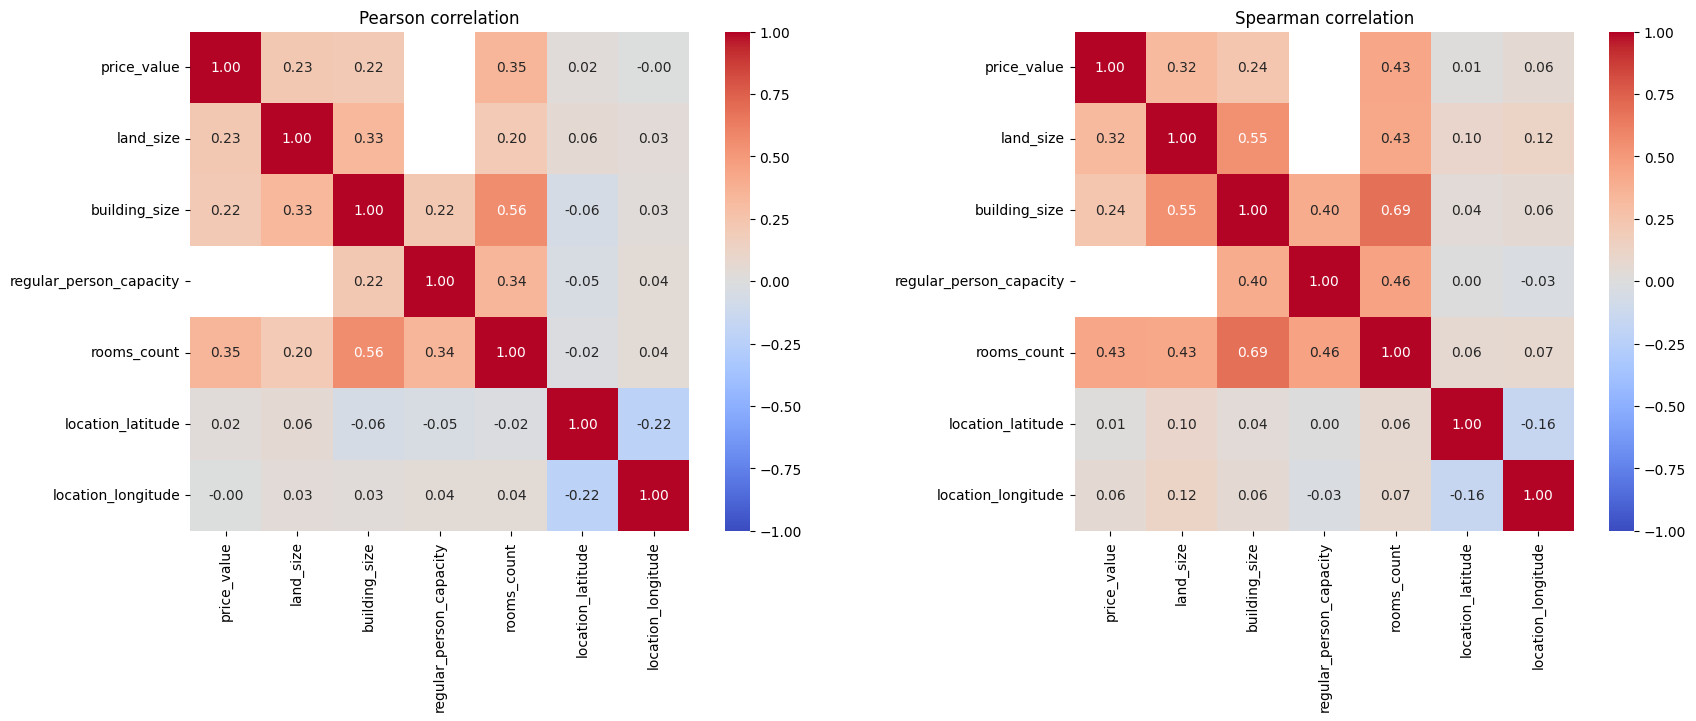

In [46]:
# correlation matrix

corr_pearson = df_q8[q8_cols].corr()
corr_spearman = df_q8[q8_cols].corr(method='spearman')

print(corr_pearson)
print(corr_spearman)

fig, axes = plt.subplots(1,2,figsize=(18, 7))

sns.heatmap(corr_pearson,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True,ax=axes[0])
axes[0].set_title('Pearson correlation')

sns.heatmap(corr_spearman, annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True,ax=axes[1])
axes[1].set_title('Spearman correlation')

plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Computed both Pearson and Spearman</li>
<li>Pearson assumes normality and only sees linear relations, but our data is heavily skewed</li>
<li>Spearman works on ranks, so skew and outliers do not affect it and it catches any monotonic relation</li>
<li>For this data Spearman is the safer measure</li>
</ul>
</font></div>

In [47]:
# top categories

print(df_q8['city_slug'].value_counts().head())
print(df_q8['cat3_slug'].value_counts().head())

city_slug
tehran     190904
mashhad     69032
karaj       49367
shiraz      37141
isfahan     36953
Name: count, dtype: int64
cat3_slug
apartment-sell      303385
apartment-rent      211880
plot-old            133570
house-villa-sell    121753
house-villa-rent     64678
Name: count, dtype: int64


(84586, 9)


                    price_value  building_size  rooms_count  \
price_value            1.000000       0.813480     0.653539   
building_size          0.813480       1.000000     0.809879   
rooms_count            0.653539       0.809879     1.000000   
location_latitude      0.297892       0.221820     0.190861   
location_longitude     0.080948       0.033873     0.011717   

                    location_latitude  location_longitude  
price_value                  0.297892            0.080948  
building_size                0.221820            0.033873  
rooms_count                  0.190861            0.011717  
location_latitude            1.000000           -0.322409  
location_longitude          -0.322409            1.000000  
                    price_value  building_size  rooms_count  \
price_value            1.000000       0.822727     0.699217   
building_size          0.822727       1.000000     0.866317   
rooms_count            0.699217       0.866317     1.000000   
location_

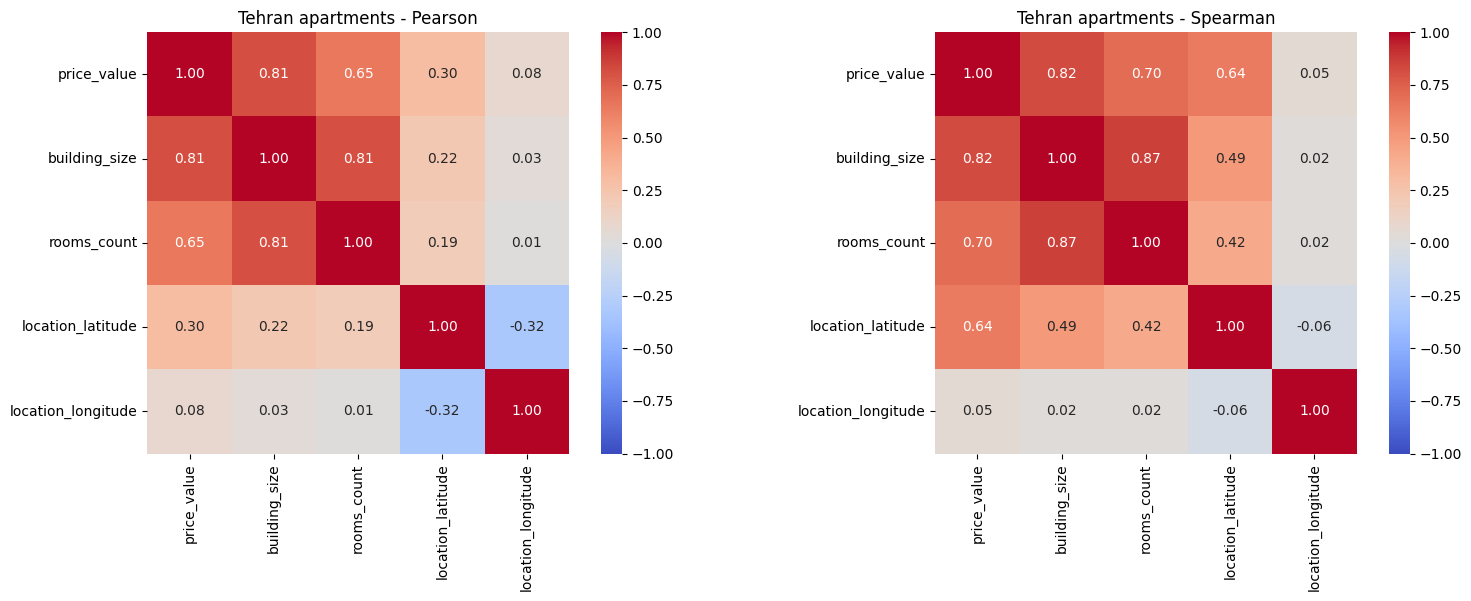

In [48]:
# homogeneous subset

subset = df_q8[(df_q8['city_slug'] == 'tehran') & (df_q8['cat3_slug'] == 'apartment-sell')]
print(subset.shape)

subset_cols = ['price_value','building_size','rooms_count','location_latitude','location_longitude']

corr_subset_pearson = subset[subset_cols].corr()
corr_subset_spearman = subset[subset_cols].corr(method='spearman')

print(corr_subset_pearson)
print(corr_subset_spearman)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_subset_pearson,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True,ax=axes[0])
axes[0].set_title('Tehran apartments - Pearson')

sns.heatmap(corr_subset_spearman,annot=True,fmt='.2f',cmap='coolwarm',vmin=-1,vmax=1,square=True,ax=axes[1])
axes[1].set_title('Tehran apartments - Spearman')

plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>To test the guess I ran the same matrix on Tehran apartment sales only, the largest homogeneous group</li>
<li>Price against size went from 0.22 to 0.81, and against latitude from 0 to 0.30</li>
<li>So the relation was there all along, hidden by mixing cities and property types</li>
<li>land_size is empty here because apartments record no land, and the limitation is that IQR capped the size at 538 m so large villas fell out</li>
</ul>
</font></div>

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Here Pearson and Spearman almost agree</li>
<li>In a homogeneous group with clean data both methods say the same thing</li>
<li>They differed much more in the pooled matrix, which shows the gap came from skew and mixing</li>
</ul>
</font></div>

count    4.683530e+05
mean     4.345253e+07
std      3.999928e+07
min      3.067485e+06
25%      1.846154e+07
50%      3.088235e+07
75%      5.284553e+07
max      2.797203e+08
Name: price_per_m2, dtype: float64
                    price_value  price_per_m2  building_size  \
price_value            1.000000      0.866699       0.817888   
price_per_m2           0.866699      1.000000       0.540172   
building_size          0.817888      0.540172       1.000000   
location_latitude      0.575340      0.650103       0.462727   
location_longitude     0.117926      0.135198       0.052590   

                    location_latitude  location_longitude  
price_value                  0.575340            0.117926  
price_per_m2                 0.650103            0.135198  
building_size                0.462727            0.052590  
location_latitude            1.000000           -0.058049  
location_longitude          -0.058049            1.000000  


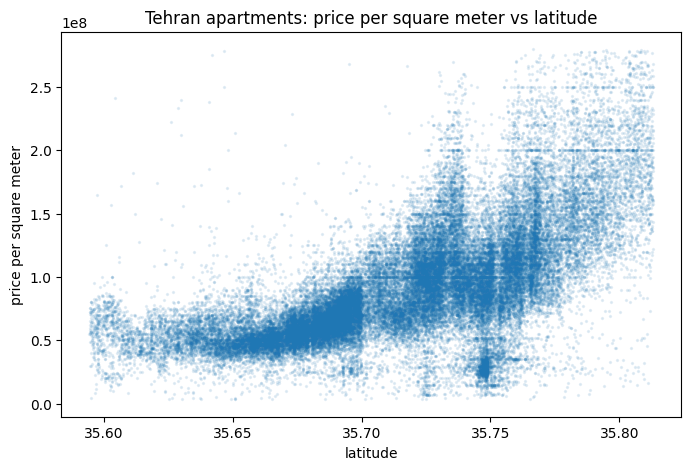

In [49]:
# price per m2

df_q8['price_per_m2'] = df_q8['price_value']/df_q8['building_size']
df_q8 = clean_outliers_log(df_q8, 'price_per_m2')

print(df_q8['price_per_m2'].describe())

subset2 = df_q8[(df_q8['city_slug'] == 'tehran') & (df_q8['cat3_slug'] == 'apartment-sell')]
lat_low, lat_high = subset2['location_latitude'].quantile([0.01,0.99])
lon_low, lon_high = subset2['location_longitude'].quantile([0.01,0.99])

subset2 = subset2[subset2['location_latitude'].between(lat_low, lat_high) & subset2['location_longitude'].between(lon_low,lon_high)]

check_cols = ['price_value','price_per_m2','building_size','location_latitude','location_longitude']
print(subset2[check_cols].corr())

plt.figure(figsize=(8, 5))
plt.scatter(subset2['location_latitude'],subset2['price_per_m2'],s=2,alpha=0.1)
plt.xlabel('latitude')
plt.ylabel('price per square meter')
plt.title('Tehran apartments: price per square meter vs latitude')
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Built a new feature, price per square metre</li>
<li>Total price carries both the size of the property and how expensive the area is, and dividing by size removes the size effect</li>
<li>The result confirms it: total price against latitude was 0.30 while price per metre is 0.54</li>
<li>On the chart it is flat up to about latitude 35.7 and then rises sharply, which is the border between south and central Tehran and the north of the city</li>
</ul>
</font></div>

In [50]:
# tehran price grid

step = 0.005
t = df_q8[(df_q8['city_slug'] == 'tehran') & (df_q8['cat3_slug'] == 'apartment-sell')]
t = t.dropna(subset=['price_per_m2','location_latitude','location_longitude']).copy()

la1, la2 = t['location_latitude'].quantile([0.01,0.99])
lo1, lo2 = t['location_longitude'].quantile([0.01,0.99])
t = t[t['location_latitude'].between(la1,la2) & t['location_longitude'].between(lo1, lo2)]

t['glat'] = (t['location_latitude'] / step).round() * step
t['glon'] = (t['location_longitude'] / step).round() * step

grid = t.groupby(['glat','glon'])['price_per_m2'].agg(['median','size'])
grid = grid[grid['size'] >= 20].reset_index()

print(grid.shape)
print('correlation price and latitude:',round(grid['median'].corr(grid['glat']),3))

(881, 4)
correlation price and latitude: 0.776


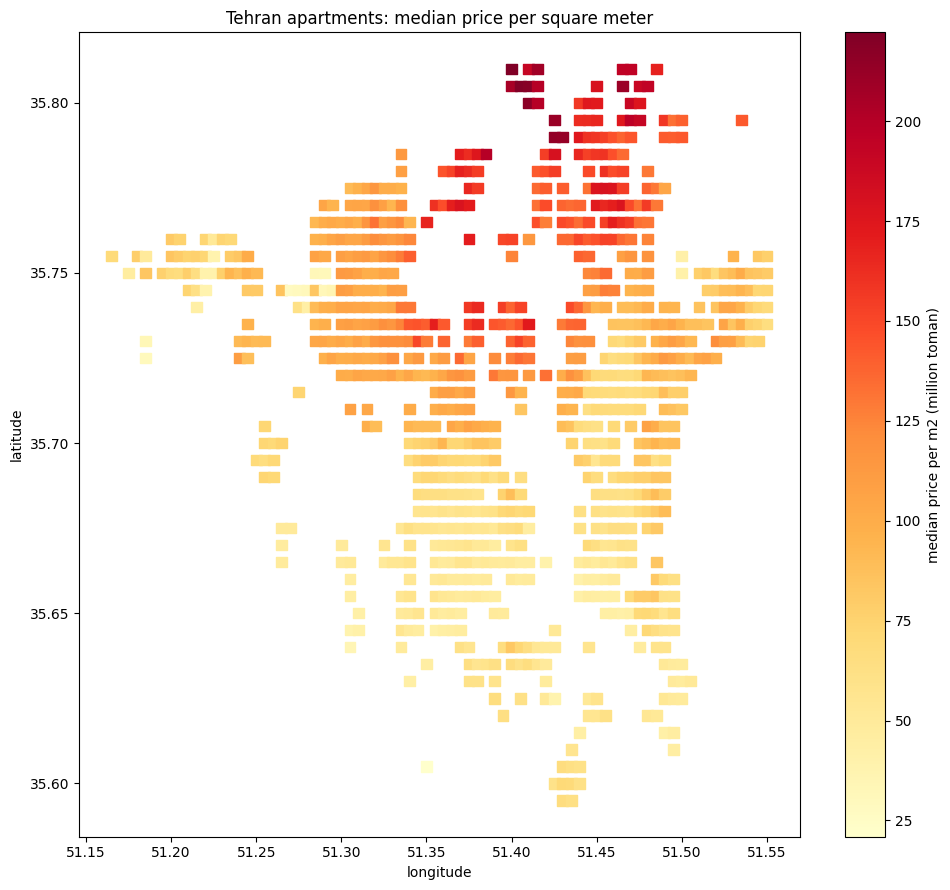

In [51]:
# static price map

fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(grid['glon'],grid['glat'],c=grid['median'] / 1e6,cmap='YlOrRd', s=60,marker='s')
plt.colorbar(sc, ax=ax, label='median price per m2 (million toman)')
ax.set_title('Tehran apartments: median price per square meter')
ax.set_xlabel('longitude')
ax.set_ylabel('latitude')
plt.tight_layout()
plt.show()

In [52]:
# folium price map

import branca.colormap as cm
lo, hi = grid['median'].quantile([0.05,0.95])
colormap = cm.linear.YlOrRd_09.scale(lo, hi)
colormap.caption = 'median price per m2 (toman)'
m2 = folium.Map(location=[t['location_latitude'].median(),t['location_longitude'].median()],zoom_start=11,tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',attr='Esri')

for _, row in grid.iterrows():
    folium.Rectangle([[row['glat'] - step/2, row['glon'] - step/2],[row['glat'] + step/2, row['glon'] + step/2]],weight=0, fill=True,fill_opacity=0.6,fill_color=colormap(min(max(row['median'],lo),hi)),tooltip=f"{row['median']/1e6:.0f} M/m2, n={int(row['size'])}").add_to(m2)

colormap.add_to(m2)
m2.save(str(MAPS_DIR / "q8_tehran_price.html"))

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Drew the price per metre of Tehran apartments on the map too</li>
<li>Split the city into cells of about 500 m, took the median price per metre of each cell and dropped cells with fewer than 20 ads</li>
<li>The reason is that a plain heatmap of the ads shows ad density, not price: wherever there are more ads it looks hotter even if they are cheap</li>
<li>The result matches what the correlation showed, the further north the more expensive, about 25 to 50 million in the south and above 200 million per metre in the north</li>
</ul>
</font></div>

---
## ۹. جغرافیای امکانات رفاهی

In [53]:
# load Q9 columns

q9_columns = ['has_balcony','has_elevator','has_security_guard','has_barbecue','has_pool','city_slug','cat3_slug','location_longitude','location_latitude']
df_q9 = pd.read_csv('../data/Divar.csv', usecols=q9_columns)
df_q9.shape

(1000000, 9)

In [54]:
# unify booleans

options_cols = ['has_balcony','has_elevator','has_security_guard','has_barbecue','has_pool']

for col in options_cols:
    print(df_q9[col].value_counts(dropna=False))

def clean_boolean_columns(data,options):
    """convert mixed true/false values (bool and string) to 1 and 0 also Anything else becomes NaN."""
    mapping = {True: 1,'true': 1,'True': 1,False: 0,'false': 0,'False': 0}
    for col in options:
        data[col] = data[col].map(mapping)
    return data
df_q9 = clean_boolean_columns(df_q9, options_cols)

for col in options_cols:
    print(df_q9[col].value_counts(dropna=False))


has_balcony
NaN         493589
true        392096
false        88855
True         20692
False         4545
unselect       223
Name: count, dtype: int64
has_elevator
NaN      458251
True     365148
False    176601
Name: count, dtype: int64
has_security_guard
NaN      968688
False     24631
True       6681
Name: count, dtype: int64
has_barbecue
NaN      968802
False     23377
True       7821
Name: count, dtype: int64
has_pool
NaN      970610
False     25669
True       3721
Name: count, dtype: int64


has_balcony
NaN    493812
1.0    412788
0.0     93400
Name: count, dtype: int64
has_elevator
NaN    458251
1.0    365148
0.0    176601
Name: count, dtype: int64
has_security_guard
NaN    968688
0.0     24631
1.0      6681
Name: count, dtype: int64
has_barbecue
NaN    968802
0.0     23377
1.0      7821
Name: count, dtype: int64
has_pool
NaN    970610
0.0     25669
1.0      3721
Name: count, dtype: int64


<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>has_balcony had five different shapes: true, True, false, False and unselect, while the other columns were plain booleans</li>
<li>Mapped them all to 0 and 1 with one function</li>
<li>Left unselect empty rather than 0, because the user simply did not answer and we do not know, and writing 0 would add information that does not exist</li>
</ul>
</font></div>

In [55]:
# options by type

df_q9.groupby('cat3_slug')[options_cols].count()

,has_balcony,has_elevator,has_security_guard,has_barbecue,has_pool
cat3_slug,,,,,
apartment-rent,125302,211867,0,0,0
apartment-sell,194485,303378,1,1,1
house-villa-rent,64663,0,5021,5107,4991
house-villa-sell,121737,0,22211,21841,20234
industry-agriculture-business-rent,0,0,0,0,0
industry-agriculture-business-sell,0,1,0,0,0
office-rent,0,21348,0,0,0
office-sell,0,5155,0,0,0
partnership,0,0,0,0,0


In [56]:
# coverage checks

print(df_q9[options_cols].notna().all(axis=1).sum())
print(df_q9[['has_balcony','has_elevator']].notna().all(axis=1).sum())
print(df_q9[['has_security_guard','has_barbecue','has_pool']].notna().all(axis=1).sum())
print(df_q9['city_slug'].nunique())
print(df_q9['city_slug'].isna().mean())

0
319787
28842
421
2e-06


In [57]:
# counts and shares

counts = df_q9.groupby('city_slug')[options_cols].count()
shares = df_q9.groupby('city_slug')[options_cols].mean()

shares_ok = shares[counts >= 200]

for col in options_cols:
    print(col)
    print(shares_ok[col].dropna().sort_values(ascending=False).head(10))
    print()

has_balcony
city_slug
pardis-city          0.991299
garmdareh            0.985294
parand-city          0.983022
kelarabad            0.975124
andisheh-new-town    0.966881
izadshahr            0.961864
nashtarud            0.961373
nowshahr             0.960497
rudehen              0.957570
sorkhrood            0.953166
Name: has_balcony, dtype: float64

has_elevator
city_slug
garmdareh       0.958684
sorkhrood       0.945122
pardis-city     0.930835
sadra           0.883479
izadshahr       0.862069
urmia           0.861374
babolsar        0.854563
parand-city     0.851244
gonbad-kavus    0.846405
kahrizak        0.845347
Name: has_elevator, dtype: float64

has_security_guard
city_slug
chamestan       0.509036
nur             0.469666
royan           0.420875
mahmudabad      0.396364
izadshahr       0.371212
amol            0.336612
nowshahr        0.334525
sorkhrood       0.330793
salman-shahr    0.308571
kelarestan      0.259649
Name: has_security_guard, dtype: float64

has_barbecue


In [58]:
# totals by city

totals = df_q9.groupby('city_slug')[options_cols].sum()

for col in options_cols:
    print(col)
    print(totals[col].dropna().sort_values(ascending=False).head(10))
    print()

has_balcony
city_slug
tehran               90464.0
mashhad              28854.0
karaj                26013.0
isfahan              15225.0
shiraz               13566.0
andisheh-new-town    13546.0
tabriz               10200.0
ahvaz                 7156.0
kermanshah            7066.0
rasht                 6947.0
Name: has_balcony, dtype: float64

has_elevator
city_slug
tehran               117558.0
mashhad               26310.0
karaj                 23866.0
shiraz                15178.0
isfahan               12928.0
andisheh-new-town     10360.0
tabriz                 9446.0
pardis-city            9192.0
ahvaz                  8177.0
parand-city            7256.0
Name: has_elevator, dtype: float64

has_security_guard
city_slug
chamestan       1690.0
nur             1138.0
mahmudabad       654.0
nowshahr         468.0
amol             308.0
sorkhrood        217.0
ramsar           198.0
izadshahr        147.0
royan            125.0
salman-shahr     108.0
Name: has_security_guard, dtype: fl

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>These five amenities are really two families: elevator is only recorded for apartments and offices, guard, barbecue and pool only for villas</li>
<li>No property has all five, so I looked at each one separately</li>
<li>Between count and share I chose share, because the question asks in which regions they are, not where the market is bigger</li>
<li>With counts Tehran always wins simply because it has the most ads</li>
<li>Cities with fewer than 200 ads were dropped, otherwise a city with a single ad reaches 100% and tops the list</li>
</ul>
</font></div>

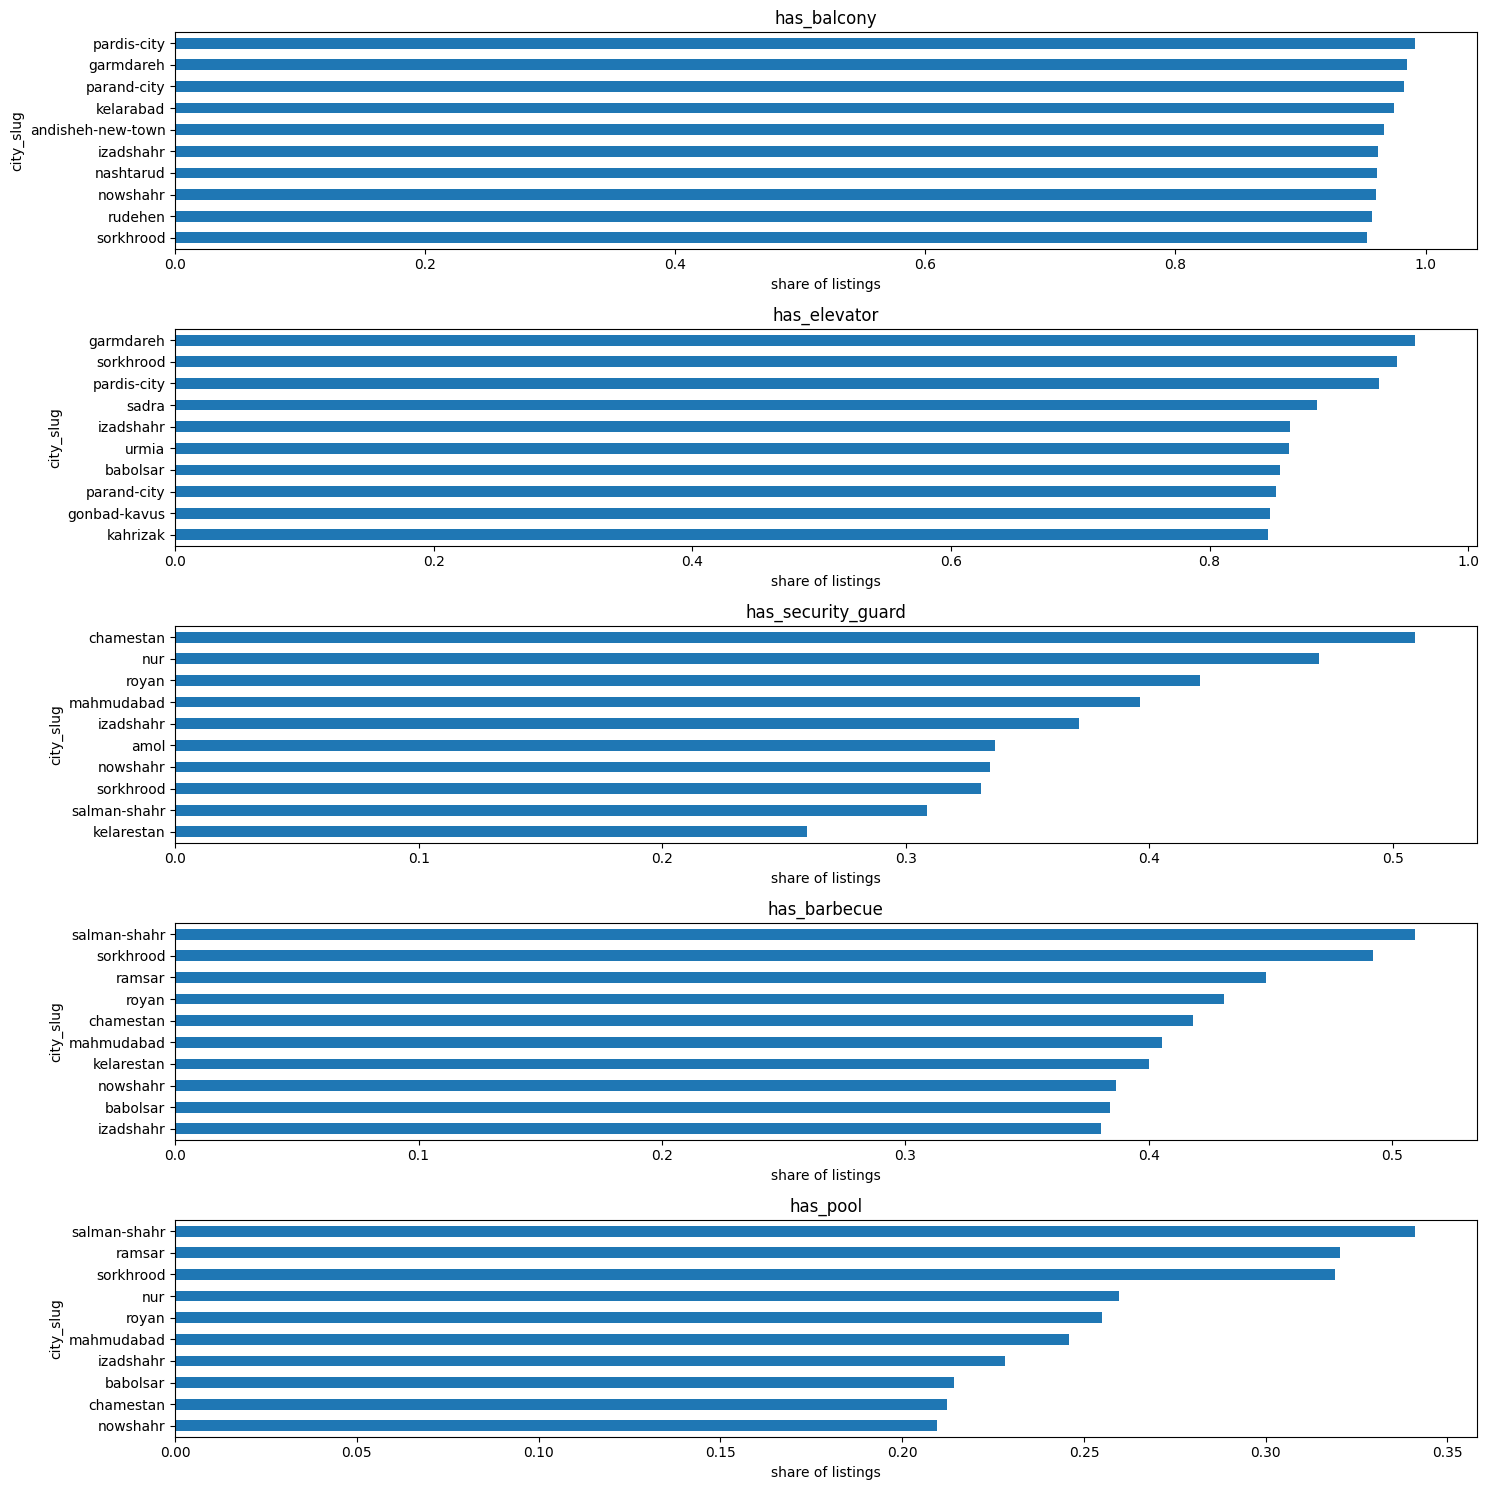

In [59]:
# top cities chart

fig, axes = plt.subplots(nrows=5, ncols=1,figsize=(15, 15))
for i, col in enumerate(options_cols):
    shares_ok[col].dropna().sort_values(ascending=False).head(10)[::-1].plot(kind='barh',ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('share of listings')

plt.tight_layout()
plt.show()

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Two clearly separate patterns came out</li>
<li>Balcony and elevator are led by new towns such as Pardis, Parand, Andisheh and Garmdareh, close to 100%, because their buildings are new and both have become standard in new construction</li>
<li>Guard, barbecue and pool are all concentrated in the northern coastal towns such as Chamestan, Nur, Ramsar, Salman Shahr and Mahmudabad, because holiday villas are common there and these amenities belong to villas, not apartments</li>
</ul>
</font></div>

In [60]:
# iran border — downloaded once, then read from the cached file

IRAN_GEOJSON = MAPS_DIR / "iran.geojson"
NATURAL_EARTH = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
                 "master/geojson/ne_10m_admin_0_countries.geojson")

if IRAN_GEOJSON.exists():
    iran = gpd.read_file(IRAN_GEOJSON)
else:
    world = gpd.read_file(NATURAL_EARTH)
    iran = world[world["ADMIN"] == "Iran"]
    iran.to_file(IRAN_GEOJSON, driver="GeoJSON")

print(len(iran))
print(iran.total_bounds)

1
[44.014863 25.059408 63.319628 39.771527]


In [61]:
# city coordinates

city_coords = df_q9.groupby('city_slug')[['location_longitude','location_latitude']].median()
print(city_coords.shape)
print(city_coords.head())

(421, 2)
           location_longitude  location_latitude
city_slug                                       
Iranshahr           60.677567          27.203257
Kordkuy             54.119755          36.788620
aalasht             52.868591          36.077824
abadan              48.289742          30.347481
abadeh              52.645699          31.160688


In [62]:
# join shares

city_map = shares.join(city_coords)
print(city_map.shape)
print(city_map.head())
print(city_map[['location_latitude','location_longitude']].isna().sum())

(421, 7)
           has_balcony  has_elevator  has_security_guard  has_barbecue  \
city_slug                                                                
Iranshahr     0.361979      0.110092            0.000000      0.000000   
Kordkuy       0.814286      0.367188            0.019231      0.038462   
aalasht       0.956522           NaN            0.409091      0.500000   
abadan        0.518378      0.523921            0.000000      0.000000   
abadeh        0.632911      0.116564            0.000000      0.000000   

           has_pool  location_longitude  location_latitude  
city_slug                                                   
Iranshahr       0.0           60.677567          27.203257  
Kordkuy         0.0           54.119755          36.788620  
aalasht         0.0           52.868591          36.077824  
abadan          0.0           48.289742          30.347481  
abadeh          0.0           52.645699          31.160688  
location_latitude     0
location_longitude   

In [63]:
# drop outside iran

iran_shape = iran.geometry.union_all()
city_gdf = gpd.GeoDataFrame(city_map,geometry=gpd.points_from_xy(city_map['location_longitude'],city_map['location_latitude']),crs='EPSG:4326')
iran_buffered = iran_shape.buffer(0.05)
inside = city_gdf.within(iran_buffered)
city_map_ok = city_gdf[inside]
print(city_map_ok.shape)
print('inside:', inside.sum(),'outside:',(~inside).sum())
print(city_gdf[~inside])

(421, 8)


inside: 421 outside: 0
Empty GeoDataFrame
Columns: [has_balcony, has_elevator, has_security_guard, has_barbecue, has_pool, location_longitude, location_latitude, geometry]
Index: []


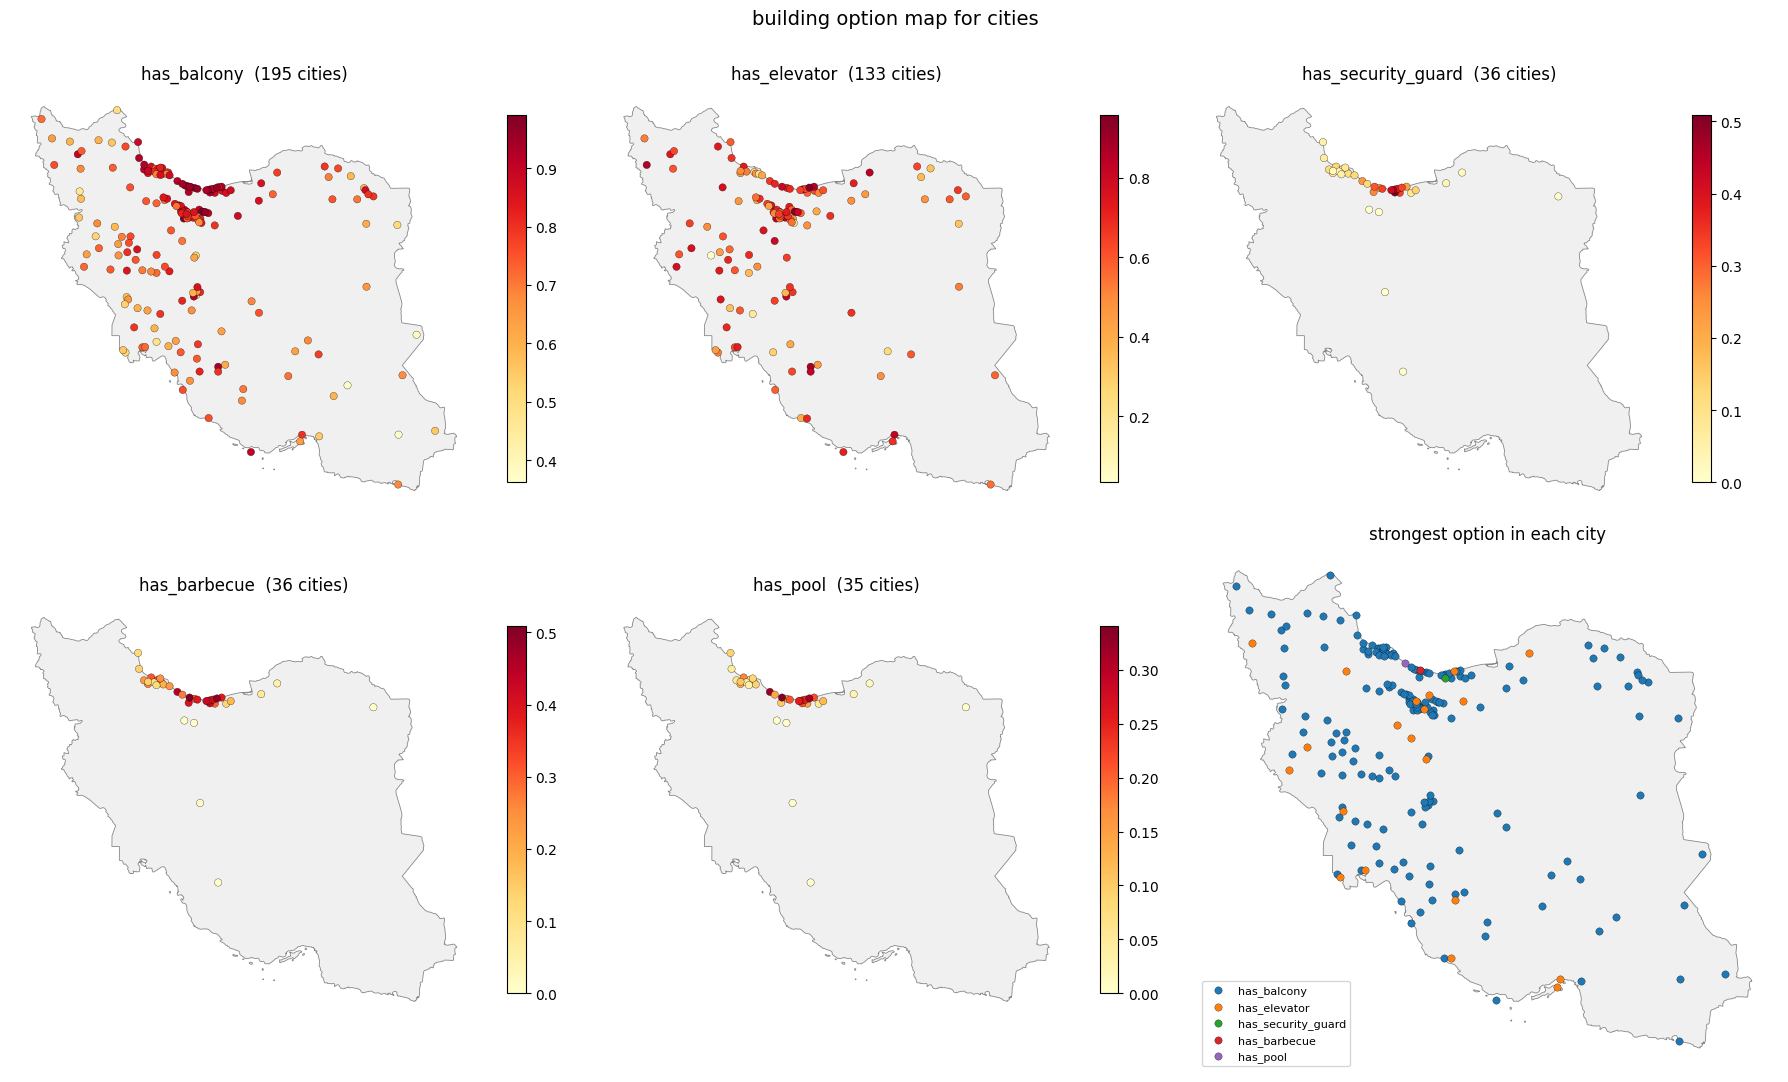

In [64]:
# static map

fig,axes = plt.subplots(2,3,figsize=(18, 11))
axes = axes.flatten()

for i,col in enumerate(options_cols):
    enough = counts[col] >= 200
    sel = city_map_ok[enough.reindex(city_map_ok.index,fill_value=False)].dropna(subset=[col])
    iran.plot(ax=axes[i],color='#f0f0f0',edgecolor='#888',linewidth=0.6)
    sc = axes[i].scatter(sel['location_longitude'],sel['location_latitude'],c=sel[col],cmap='YlOrRd',s=28,edgecolor='black',linewidth=0.2)
    plt.colorbar(sc, ax=axes[i],shrink=0.7)
    axes[i].set_title(f'{col}  ({len(sel)} cities)')
    axes[i].set_axis_off()

rel = pd.DataFrame(index=city_map_ok.index)
for col in options_cols:
    enough = counts[col] >= 200
    s = city_map_ok[col].where(enough.reindex(city_map_ok.index, fill_value=False))
    rel[col] = s / s.max()

top = rel.dropna(how='all').idxmax(axis=1)

iran.plot(ax=axes[5],color='#f0f0f0',edgecolor='#888',linewidth=0.6)
for col, colour in zip(options_cols,['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd']):
    pts = city_map_ok.loc[top[top == col].index]
    axes[5].scatter(pts['location_longitude'],pts['location_latitude'],c=colour,s=28,edgecolor='black',linewidth=0.2,label=col)

axes[5].set_title('strongest option in each city')
axes[5].legend(fontsize=8,loc='lower left')
axes[5].set_axis_off()

plt.suptitle('building option map for cities', fontsize=14)
plt.tight_layout()
plt.show()

In [65]:
# folium map

m = folium.Map(location=[32.4, 53.7],zoom_start=5,tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',attr='Esri')
folium.GeoJson(iran, name='Iran border').add_to(m)

colormap = cm.linear.YlOrRd_09.scale(0, 1)
colormap.caption = 'share of listings, relative to the top city of that option (hover a circle for the real %)'

for col in options_cols:
    enough = counts[col] >= 200
    sel = city_map_ok[enough.reindex(city_map_ok.index, fill_value=False)].dropna(subset=[col])
    top = sel[col].max()
    fg = folium.FeatureGroup(name=f'{col} ({len(sel)} cities, max {top:.0%})')
    for city,row in sel.iterrows():
        folium.CircleMarker([row['location_latitude'],row['location_longitude']],radius=5,weight=0,fill=True,fill_opacity=0.85,fill_color=colormap(row[col]/top),tooltip=f"{city}: {row[col]:.0%}").add_to(fg)
    fg.add_to(m)

colormap.add_to(m)
folium.LayerControl(collapsed=False).add_to(m)
m.save(str(MAPS_DIR / "q9_map.html"))

<div dir="ltr" align="left"><font color="#0099cc">
<ul>
<li>Drew the Q9 result on the map of Iran as well</li>
<li>Took each city's coordinates from the median of its own ads, which does not move when a few coordinates are wrong</li>
<li>Gave the border a 5 km margin, because Bandar Abbas and Konarak are coastal and fell outside without it</li>
<li>Each of the five maps has its own colour scale, because the maximum share differs per amenity</li>
<li>The sixth panel divides every share by its own maximum and shows which amenity each city stands out in, which separates the new towns from the northern coast in one picture</li>
</ul>
</font></div>